In [9]:
# Prompt: Find the two downloaded GHSL ZIP archives anywhere inside the project data folder.

from pathlib import Path
import pandas as pd
matches = sorted((PROJECT_ROOT / "data").rglob("GHS_*.zip"))

print("GHSL archives found:")
for file_path in matches:
    print("-", file_path)

GHSL archives found:
- F:\UrbanEV_Charging_Demand\data\raw\ghsl\GHS_BUILT_S_E2020_GLOBE_R2023A_54009_1000_V1_0.zip
- F:\UrbanEV_Charging_Demand\data\raw\ghsl\GHS_POP_E2020_GLOBE_R2023A_54009_1000_V1_0.zip


In [3]:
# Prompt: Inspect the downloaded GHSL archives and identify their raster files for the Isfahan case study.

from zipfile import ZipFile

GHSL_RAW_DIR = PROJECT_ROOT / "data" / "raw" / "ghsl"
ghsl_archives = sorted(GHSL_RAW_DIR.glob("GHS_*.zip"))

for archive_path in ghsl_archives:
    with ZipFile(archive_path) as archive:
        raster_files = [
            name for name in archive.namelist()
            if name.lower().endswith((".tif", ".tiff"))
        ]

    print(f"\n{archive_path.name}")
    for raster_file in raster_files:
        print("-", raster_file)


GHS_BUILT_S_E2020_GLOBE_R2023A_54009_1000_V1_0.zip
- GHS_BUILT_S_E2020_GLOBE_R2023A_54009_1000_V1_0.tif

GHS_POP_E2020_GLOBE_R2023A_54009_1000_V1_0.zip
- GHS_POP_E2020_GLOBE_R2023A_54009_1000_V1_0.tif


In [4]:
# Prompt: Extract the GHSL population and built-surface rasters for the Isfahan case study while preserving the raw ZIP archives.

from zipfile import ZipFile

GHSL_INTERIM_DIR = PROJECT_ROOT / "data" / "interim" / "ghsl_rasters"
GHSL_INTERIM_DIR.mkdir(parents=True, exist_ok=True)

extracted_files = []

for archive_path in ghsl_archives:
    with ZipFile(archive_path) as archive:
        raster_names = [
            name for name in archive.namelist()
            if name.lower().endswith((".tif", ".tiff"))
        ]

        for raster_name in raster_names:
            target_path = GHSL_INTERIM_DIR / Path(raster_name).name

            if not target_path.exists():
                with archive.open(raster_name) as source, open(target_path, "wb") as target:
                    target.write(source.read())

            extracted_files.append(target_path)

print("Extracted raster files:")
for file_path in extracted_files:
    print("-", file_path.name)

Extracted raster files:
- GHS_BUILT_S_E2020_GLOBE_R2023A_54009_1000_V1_0.tif
- GHS_POP_E2020_GLOBE_R2023A_54009_1000_V1_0.tif


In [5]:
# Prompt: Verify GHSL raster metadata and confirm whether both rasters cover the Isfahan study area.

import rasterio
from rasterio.warp import transform_bounds

for raster_path in extracted_files:
    with rasterio.open(raster_path) as raster:
        bounds_wgs84 = transform_bounds(
            raster.crs,
            "EPSG:4326",
            *raster.bounds,
            densify_pts=21,
        )

        print(f"\n{raster_path.name}")
        print("CRS:", raster.crs)
        print("Raster size:", raster.width, "×", raster.height)
        print("Resolution:", raster.res)
        print("Bounds in WGS84 (west, south, east, north):")
        print(tuple(round(value, 4) for value in bounds_wgs84))

        isfahan_lon, isfahan_lat = 51.6680, 32.6546
        west, south, east, north = bounds_wgs84
        covers_isfahan = west <= isfahan_lon <= east and south <= isfahan_lat <= north

        print("Covers Isfahan center:", covers_isfahan)


GHS_BUILT_S_E2020_GLOBE_R2023A_54009_1000_V1_0.tif
CRS: ESRI:54009
Raster size: 36082 × 18000
Resolution: (1000.0, 1000.0)
Bounds in WGS84 (west, south, east, north):
(0.0, -89.0914, 0.0, 89.0914)
Covers Isfahan center: False

GHS_POP_E2020_GLOBE_R2023A_54009_1000_V1_0.tif
CRS: ESRI:54009
Raster size: 36082 × 18000
Resolution: (1000.0, 1000.0)
Bounds in WGS84 (west, south, east, north):
(0.0, -89.0914, 0.0, 89.0914)
Covers Isfahan center: False


In [6]:
# Prompt: Confirm that the global GHSL rasters contain valid population and built-surface pixels at Isfahan.

from pyproj import Transformer

isfahan_lon, isfahan_lat = 51.6680, 32.6546

for raster_path in extracted_files:
    with rasterio.open(raster_path) as raster:
        transformer = Transformer.from_crs(
            "EPSG:4326",
            raster.crs,
            always_xy=True,
        )

        isfahan_x, isfahan_y = transformer.transform(
            isfahan_lon,
            isfahan_lat,
        )

        row, col = raster.index(isfahan_x, isfahan_y)
        inside_raster = (
            0 <= row < raster.height
            and 0 <= col < raster.width
        )

        pixel_value = None
        if inside_raster:
            pixel_value = raster.read(1, window=((row, row + 1), (col, col + 1)))[0, 0]

        print(f"\n{raster_path.name}")
        print("Isfahan pixel (row, col):", (row, col))
        print("Inside raster:", inside_raster)
        print("Pixel value at Isfahan center:", pixel_value)


GHS_BUILT_S_E2020_GLOBE_R2023A_54009_1000_V1_0.tif
Isfahan pixel (row, col): (5047, 22695)
Inside raster: True
Pixel value at Isfahan center: 377001

GHS_POP_E2020_GLOBE_R2023A_54009_1000_V1_0.tif
Isfahan pixel (row, col): (5047, 22695)
Inside raster: True
Pixel value at Isfahan center: 11999.781950831413


In [7]:
# Prompt: Download and inspect the administrative boundary of Isfahan, Iran, for the EV-charging siting case study.

import osmnx as ox
import geopandas as gpd

isfahan_boundary = ox.geocode_to_gdf(
    "Isfahan, Isfahan Province, Iran",
    which_result=0,
)

isfahan_boundary = isfahan_boundary.to_crs("EPSG:4326")

print("Boundary records:", len(isfahan_boundary))
print("Geometry type:", isfahan_boundary.geometry.iloc[0].geom_type)
print("Area in geographic CRS is not used for analysis.")
print("WGS84 bounds:", tuple(round(value, 5) for value in isfahan_boundary.total_bounds))

isfahan_boundary[["display_name", "geometry"]]

Boundary records: 1
Geometry type: Polygon
Area in geographic CRS is not used for analysis.
WGS84 bounds: (np.float64(51.52564), np.float64(32.50464), np.float64(51.86537), np.float64(32.8204))


,display_name,geometry
0,"Isfahan, بخش مرکزی شهرستان اصفهان, Isfahan Cou...","POLYGON ((51.52564 32.77451, 51.5276 32.76572,..."


In [10]:
# Prompt: Compare OSM geocoding candidates for Isfahan and identify the appropriate urban boundary.

candidate_rows = []

for result_number in range(6):
    try:
        candidate = ox.geocode_to_gdf(
            "Isfahan, Isfahan Province, Iran",
            which_result=result_number,
        ).to_crs("EPSG:32639")

        candidate_rows.append(
            {
                "result_number": result_number,
                "display_name": candidate["display_name"].iloc[0],
                "geometry_type": candidate.geometry.iloc[0].geom_type,
                "area_km2": candidate.geometry.area.iloc[0] / 1_000_000,
                "bounds_utm": tuple(
                    round(value, 0)
                    for value in candidate.total_bounds
                ),
            }
        )
    except Exception as error:
        candidate_rows.append(
            {
                "result_number": result_number,
                "display_name": f"Not available: {error}",
                "geometry_type": None,
                "area_km2": None,
                "bounds_utm": None,
            }
        )

isfahan_boundary_candidates = pd.DataFrame(candidate_rows)
isfahan_boundary_candidates

,result_number,display_name,geometry_type,area_km2,bounds_utm
0,0,"Isfahan, بخش مرکزی شهرستان اصفهان, Isfahan Cou...",Polygon,549.888804,"(549228.0, 3596576.0, 581128.0, 3631522.0)"
1,1,"Isfahan, بخش مرکزی شهرستان اصفهان, Isfahan Cou...",Polygon,549.888804,"(549228.0, 3596576.0, 581128.0, 3631522.0)"
2,2,Not available: Nominatim returned 1 result(s) ...,None,NaN,None
3,3,Not available: Nominatim returned 1 result(s) ...,None,NaN,None
4,4,Not available: Nominatim returned 1 result(s) ...,None,NaN,None
5,5,Not available: Nominatim returned 1 result(s) ...,None,NaN,None


In [11]:
# Prompt: Retrieve OSM administrative boundaries around urban Isfahan through Overpass and identify the city-level candidate.

isfahan_bbox = (
    51.52,  # west
    32.48,  # south
    51.90,  # east
    32.84,  # north
)

isfahan_osm_boundaries = ox.features_from_bbox(
    bbox=isfahan_bbox,
    tags={"boundary": "administrative"},
)

isfahan_boundary_inventory = (
    isfahan_osm_boundaries
    .reset_index()
    .assign(
        name=lambda data: data.get("name", pd.Series(index=data.index)),
        name_en=lambda data: data.get("name:en", pd.Series(index=data.index)),
        admin_level=lambda data: data.get(
            "admin_level",
            pd.Series(index=data.index),
        ),
    )
    [["element", "id", "name", "name_en", "admin_level", "geometry"]]
)

isfahan_boundary_inventory[
    isfahan_boundary_inventory["name"].astype(str).str.contains(
        "اصفهان|Isfahan",
        case=False,
        na=False,
    )
]

,element,id,name,name_en,admin_level,geometry
0,relation,241475,استان اصفهان,Isfahan Province,4,"POLYGON ((49.64981 32.97176, 49.65001 32.97382..."
1,relation,6554888,شهرستان اصفهان,Isfahan County,5,"POLYGON ((51.52564 32.77451, 51.54664 32.77847..."
12,relation,6556141,بخش مرکزی شهرستان اصفهان,NaN,6,"POLYGON ((51.52564 32.77451, 51.54664 32.77847..."
39,relation,6566419,اصفهان,Isfahan,7,"POLYGON ((51.52564 32.77451, 51.54664 32.77847..."
200,relation,17231262,خانه اصفهان,khaneh esfahan,11,"POLYGON ((51.62676 32.70326, 51.62701 32.70342..."


Selected boundary: Isfahan city
OSM relation ID: 6566419
Area (km²): 549.89
UTM zone: EPSG:32639
Bounds (UTM): (np.float64(549228.0), np.float64(3596576.0), np.float64(581128.0), np.float64(3631522.0))


<Axes: >

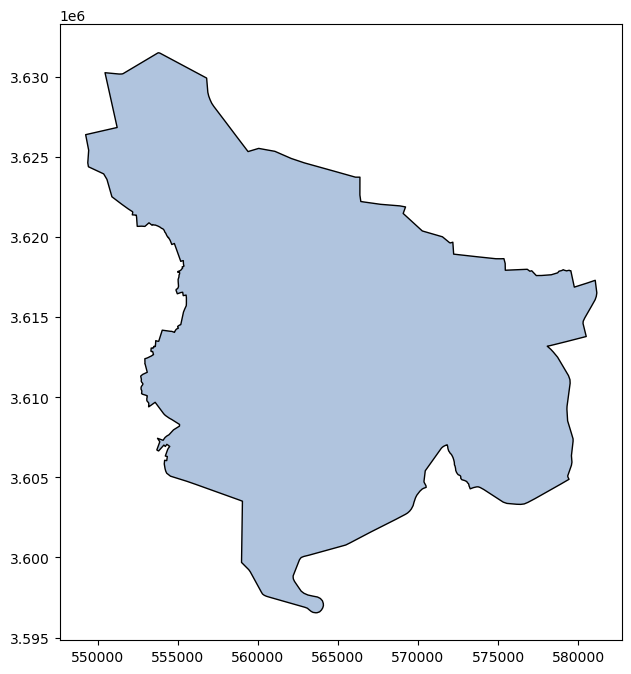

In [12]:
# Prompt: Select and validate the OSM city boundary of Isfahan for the EV-charging siting analysis.

ISFAHAN_CITY_RELATION_ID = 6566419

isfahan_boundary = (
    isfahan_osm_boundaries
    .loc[
        (isfahan_osm_boundaries.index.get_level_values("element") == "relation")
        & (isfahan_osm_boundaries.index.get_level_values("id") == ISFAHAN_CITY_RELATION_ID)
    ]
    .copy()
    .to_crs("EPSG:32639")
)

isfahan_area_km2 = isfahan_boundary.geometry.area.iloc[0] / 1_000_000
isfahan_bounds_utm = tuple(
    round(value, 0)
    for value in isfahan_boundary.total_bounds
)

print("Selected boundary: Isfahan city")
print("OSM relation ID:", ISFAHAN_CITY_RELATION_ID)
print("Area (km²):", round(isfahan_area_km2, 2))
print("UTM zone:", isfahan_boundary.crs)
print("Bounds (UTM):", isfahan_bounds_utm)

isfahan_boundary.plot(figsize=(8, 8), edgecolor="black", facecolor="lightsteelblue")

Selected boundary: Isfahan city
OSM relation ID: 6566419
Area (km²): 549.89
UTM zone: EPSG:32639
Bounds (UTM): (np.float64(549228.0), np.float64(3596576.0), np.float64(581128.0), np.float64(3631522.0))


<Axes: >

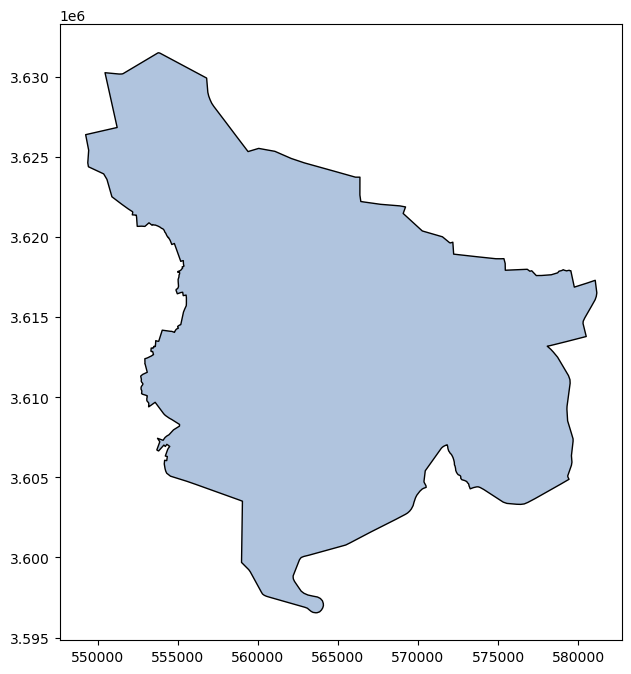

In [13]:
# Prompt: Select and validate the OSM city boundary of Isfahan for the EV-charging siting analysis.

ISFAHAN_CITY_RELATION_ID = 6566419

isfahan_boundary = (
    isfahan_osm_boundaries
    .loc[
        (isfahan_osm_boundaries.index.get_level_values("element") == "relation")
        & (isfahan_osm_boundaries.index.get_level_values("id") == ISFAHAN_CITY_RELATION_ID)
    ]
    .copy()
    .to_crs("EPSG:32639")
)

isfahan_area_km2 = isfahan_boundary.geometry.area.iloc[0] / 1_000_000
isfahan_bounds_utm = tuple(
    round(value, 0)
    for value in isfahan_boundary.total_bounds
)

print("Selected boundary: Isfahan city")
print("OSM relation ID:", ISFAHAN_CITY_RELATION_ID)
print("Area (km²):", round(isfahan_area_km2, 2))
print("UTM zone:", isfahan_boundary.crs)
print("Bounds (UTM):", isfahan_bounds_utm)

isfahan_boundary.plot(figsize=(8, 8), edgecolor="black", facecolor="lightsteelblue")

In [14]:
# Prompt: Create a 500-by-500-m analytical grid clipped to the Isfahan study boundary.

import math
import numpy as np
from shapely.geometry import box

GRID_SIZE_METERS = 500
MIN_CELL_COVERAGE = 0.10  # keep cells with at least 10% of their area inside the boundary

study_boundary_geometry = isfahan_boundary.geometry.iloc[0]
min_x, min_y, max_x, max_y = isfahan_boundary.total_bounds

grid_min_x = math.floor(min_x / GRID_SIZE_METERS) * GRID_SIZE_METERS
grid_min_y = math.floor(min_y / GRID_SIZE_METERS) * GRID_SIZE_METERS
grid_max_x = math.ceil(max_x / GRID_SIZE_METERS) * GRID_SIZE_METERS
grid_max_y = math.ceil(max_y / GRID_SIZE_METERS) * GRID_SIZE_METERS

grid_polygons = [
    box(x, y, x + GRID_SIZE_METERS, y + GRID_SIZE_METERS)
    for x in np.arange(grid_min_x, grid_max_x, GRID_SIZE_METERS)
    for y in np.arange(grid_min_y, grid_max_y, GRID_SIZE_METERS)
]

isfahan_grid = gpd.GeoDataFrame(
    {"geometry": grid_polygons},
    crs=isfahan_boundary.crs,
)

isfahan_grid["intersection_geometry"] = isfahan_grid.geometry.intersection(
    study_boundary_geometry
)
isfahan_grid["coverage_ratio"] = (
    isfahan_grid["intersection_geometry"].area
    / (GRID_SIZE_METERS ** 2)
)

isfahan_grid = (
    isfahan_grid
    .loc[isfahan_grid["coverage_ratio"] >= MIN_CELL_COVERAGE]
    .copy()
    .reset_index(drop=True)
)

isfahan_grid["geometry"] = isfahan_grid["intersection_geometry"]
isfahan_grid = isfahan_grid.drop(columns="intersection_geometry")
isfahan_grid["grid_id"] = [
    f"ISF_{cell_number:04d}"
    for cell_number in range(1, len(isfahan_grid) + 1)
]
isfahan_grid["grid_area_km2"] = isfahan_grid.geometry.area / 1_000_000

print("Grid size:", f"{GRID_SIZE_METERS} × {GRID_SIZE_METERS} m")
print("Retained grid cells:", len(isfahan_grid))
print("Study-area coverage (km²):", round(isfahan_grid["grid_area_km2"].sum(), 2))
print("Mean grid-cell area (km²):", round(isfahan_grid["grid_area_km2"].mean(), 3))

isfahan_grid[["grid_id", "coverage_ratio", "grid_area_km2", "geometry"]].head()

Grid size: 500 × 500 m
Retained grid cells: 2296
Study-area coverage (km²): 549.17
Mean grid-cell area (km²): 0.239


,grid_id,coverage_ratio,grid_area_km2,geometry
0,ISF_0001,0.253999,0.063500,"POLYGON ((549500 3625000, 549500 3624500, 5493..."
1,ISF_0002,0.195923,0.048981,"POLYGON ((549500 3625500, 549500 3625000, 5493..."
2,ISF_0003,0.287913,0.071978,"POLYGON ((549500 3626000, 549500 3625500, 5494..."
3,ISF_0004,0.416477,0.104119,"POLYGON ((549500 3626000, 549307.574 3626000, ..."
4,ISF_0005,0.508496,0.127124,"POLYGON ((549500 3624500, 550000 3624500, 5500..."


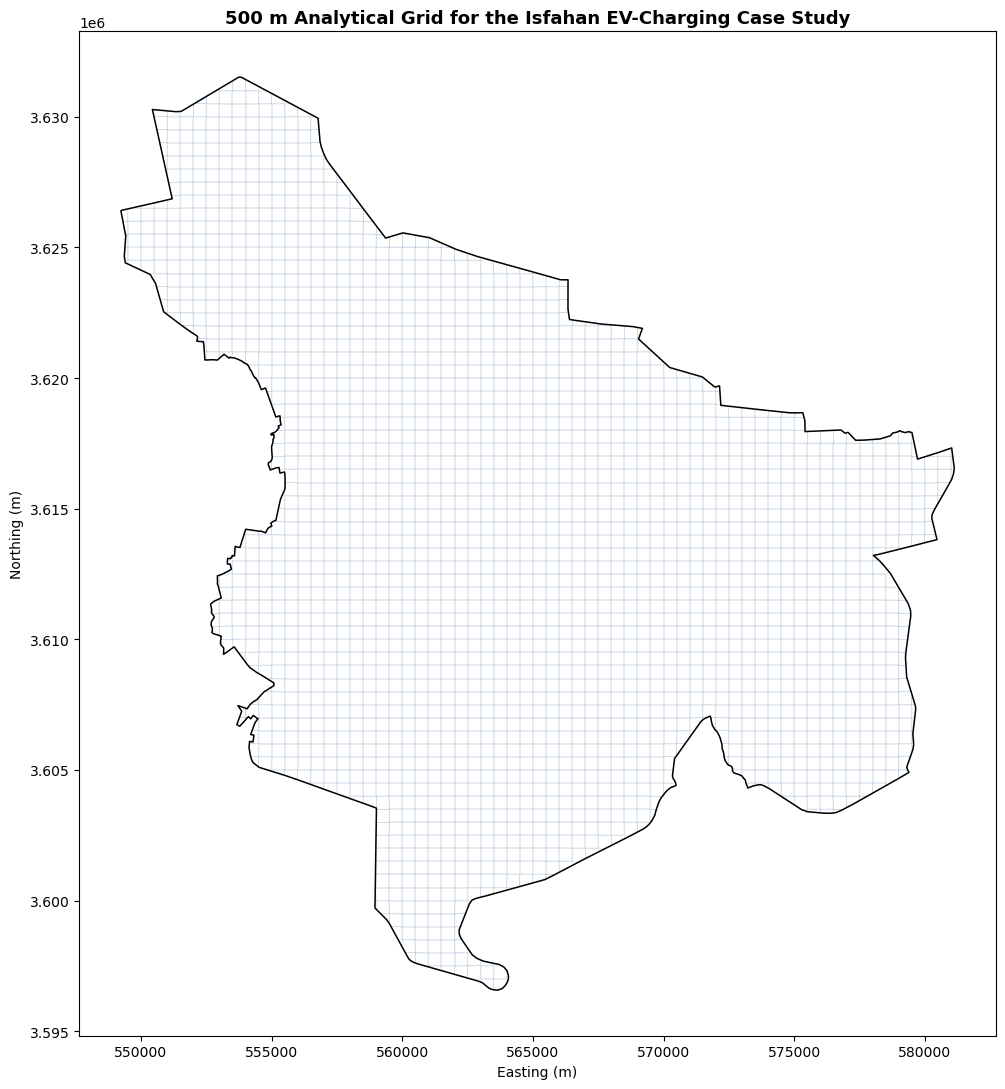

Saved grid: F:\UrbanEV_Charging_Demand\data\interim\isfahan_grid_500m.gpkg
Saved figure: F:\UrbanEV_Charging_Demand\outputs\figures\isfahan_500m_analytical_grid.png


In [15]:
# Prompt: Save and visually verify the clipped 500-m Isfahan analytical grid.

import matplotlib.pyplot as plt

INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
OUTPUT_FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"

INTERIM_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

grid_output_path = INTERIM_DIR / "isfahan_grid_500m.gpkg"
figure_output_path = OUTPUT_FIGURES_DIR / "isfahan_500m_analytical_grid.png"

isfahan_grid.to_file(
    grid_output_path,
    layer="isfahan_grid_500m",
    driver="GPKG",
)

fig, axis = plt.subplots(figsize=(11, 11))

isfahan_boundary.boundary.plot(
    ax=axis,
    color="black",
    linewidth=1.1,
    zorder=2,
)

isfahan_grid.boundary.plot(
    ax=axis,
    color="#4C78A8",
    linewidth=0.15,
    alpha=0.65,
    zorder=1,
)

axis.set_title(
    "500 m Analytical Grid for the Isfahan EV-Charging Case Study",
    fontsize=13,
    fontweight="bold",
)
axis.set_xlabel("Easting (m)")
axis.set_ylabel("Northing (m)")
axis.set_aspect("equal")

fig.tight_layout()
fig.savefig(figure_output_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved grid:", grid_output_path)
print("Saved figure:", figure_output_path)

In [16]:
# Prompt: Download, project, and save the drivable street network within the Isfahan study boundary.

import osmnx as ox

NETWORK_DIR = INTERIM_DIR / "isfahan_street_network"
NETWORK_DIR.mkdir(parents=True, exist_ok=True)

isfahan_boundary_wgs84 = isfahan_boundary.to_crs("EPSG:4326")

isfahan_drive_graph = ox.graph_from_polygon(
    polygon=isfahan_boundary_wgs84.geometry.iloc[0],
    network_type="drive",
    simplify=True,
    retain_all=True,
    truncate_by_edge=True,
)

isfahan_drive_graph = ox.project_graph(
    isfahan_drive_graph,
    to_crs="EPSG:32639",
)

ox.save_graphml(
    isfahan_drive_graph,
    NETWORK_DIR / "isfahan_drive_network.graphml",
)

isfahan_network_nodes, isfahan_network_edges = ox.graph_to_gdfs(
    isfahan_drive_graph,
    nodes=True,
    edges=True,
)

print("Network nodes:", len(isfahan_network_nodes))
print("Directed edges:", len(isfahan_network_edges))
print("Total directed length (km):", round(isfahan_network_edges["length"].sum() / 1000, 2))
print("Saved network:", NETWORK_DIR / "isfahan_drive_network.graphml")

Network nodes: 83657
Directed edges: 178148
Total directed length (km): 9953.4
Saved network: F:\UrbanEV_Charging_Demand\data\interim\isfahan_street_network\isfahan_drive_network.graphml


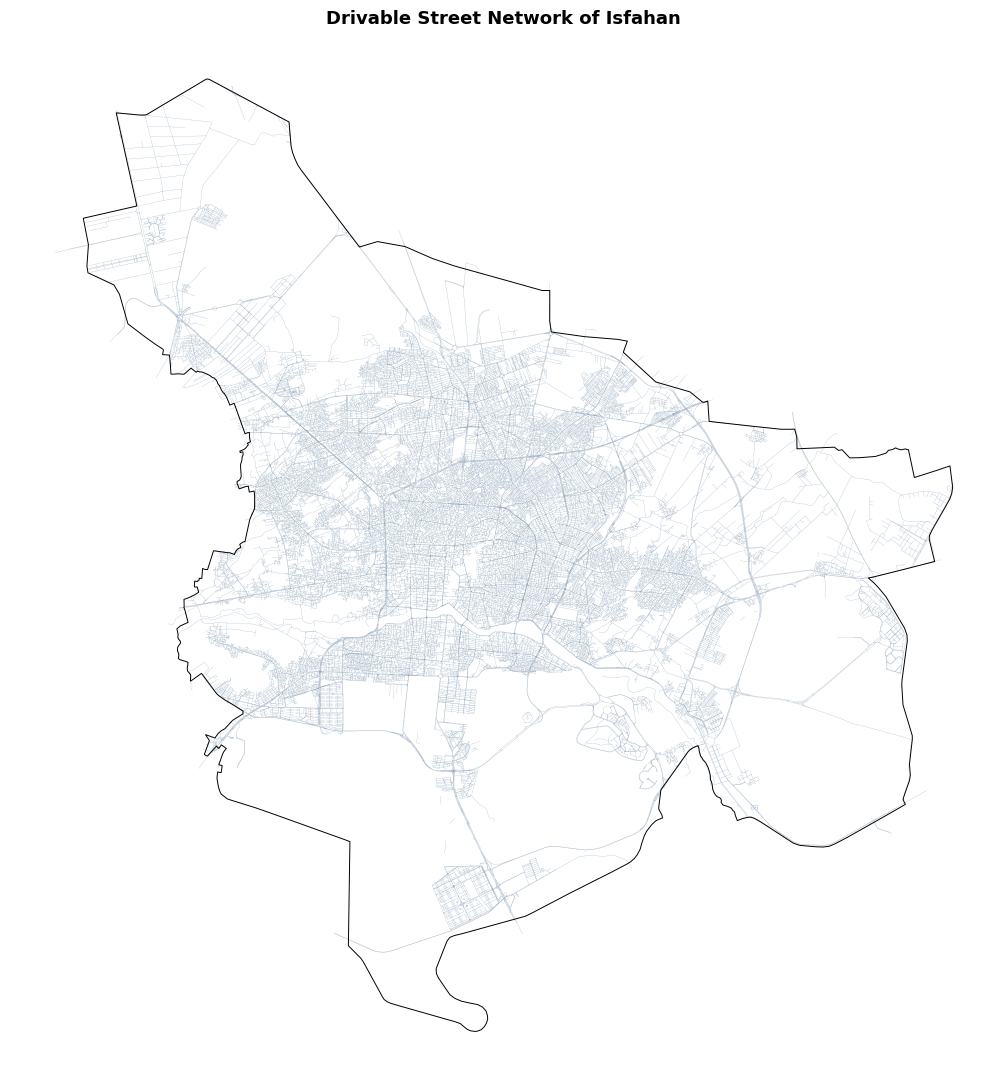

Unique street segments: 99666
Unique network length (km): 5938.41
Saved street layer: F:\UrbanEV_Charging_Demand\data\interim\isfahan_street_network\isfahan_unique_street_segments.gpkg
Saved SVG map: F:\UrbanEV_Charging_Demand\outputs\figures\isfahan_drivable_street_network.svg


In [17]:
# Prompt: Create a unique-segment street layer from the directed Isfahan road network and save a visual quality-control map.

isfahan_undirected_graph = ox.convert.to_undirected(isfahan_drive_graph)

_, isfahan_unique_segments = ox.graph_to_gdfs(
    isfahan_undirected_graph,
    nodes=True,
    edges=True,
)

isfahan_unique_segments = (
    isfahan_unique_segments
    .reset_index()
    .to_crs("EPSG:32639")
)

unique_network_length_km = isfahan_unique_segments["length"].sum() / 1000

network_gpkg_path = NETWORK_DIR / "isfahan_unique_street_segments.gpkg"
network_png_path = OUTPUT_FIGURES_DIR / "isfahan_drivable_street_network.png"
network_svg_path = OUTPUT_FIGURES_DIR / "isfahan_drivable_street_network.svg"

isfahan_unique_segments.to_file(
    network_gpkg_path,
    layer="unique_street_segments",
    driver="GPKG",
)

fig, axis = plt.subplots(figsize=(11, 11))

isfahan_boundary.boundary.plot(
    ax=axis,
    color="black",
    linewidth=0.7,
    zorder=2,
)

isfahan_unique_segments.plot(
    ax=axis,
    color="#466A8F",
    linewidth=0.12,
    alpha=0.8,
    zorder=1,
)

axis.set_title(
    "Drivable Street Network of Isfahan",
    fontsize=13,
    fontweight="bold",
)
axis.set_axis_off()
axis.set_aspect("equal")

fig.tight_layout()
fig.savefig(network_png_path, dpi=300, bbox_inches="tight")
fig.savefig(network_svg_path, format="svg", bbox_inches="tight")
plt.show()

print("Unique street segments:", len(isfahan_unique_segments))
print("Unique network length (km):", round(unique_network_length_km, 2))
print("Saved street layer:", network_gpkg_path)
print("Saved SVG map:", network_svg_path)

In [19]:
# Prompt: Download and save broad urban points of interest from OpenStreetMap for transferable Isfahan demand-potential features.

OSM_POI_TAGS = {
    "amenity": True,
    "shop": True,
    "tourism": True,
    "leisure": True,
    "office": True,
    "craft": True,
    "historic": True,
}

ox.settings.requests_timeout = 3600

isfahan_osm_pois = ox.features_from_polygon(
    polygon=isfahan_boundary_wgs84.geometry.iloc[0],
    tags=OSM_POI_TAGS,
).to_crs("EPSG:32639")

isfahan_osm_pois = (
    isfahan_osm_pois
    .loc[~isfahan_osm_pois.geometry.is_empty]
    .copy()
)

isfahan_osm_pois["poi_geometry_type"] = isfahan_osm_pois.geometry.geom_type
isfahan_osm_pois["poi_point"] = isfahan_osm_pois.geometry.representative_point()

poi_output_path = INTERIM_DIR / "isfahan_osm_pois.gpkg"

poi_index = isfahan_osm_pois.index.to_frame(index=False)

isfahan_poi_points = gpd.GeoDataFrame(
    {
        "osm_element": poi_index["element"].astype(str).to_numpy(),
        "osm_id": poi_index["id"].astype(str).to_numpy(),
        "poi_geometry_type": isfahan_osm_pois["poi_geometry_type"].to_numpy(),
    },
    geometry=isfahan_osm_pois["poi_point"].to_numpy(),
    crs="EPSG:32639",
)

poi_output_path = INTERIM_DIR / "isfahan_osm_poi_points.gpkg"

isfahan_poi_points.to_file(
    poi_output_path,
    layer="osm_poi_points",
    driver="GPKG",
)

print("Total OSM POIs:", len(isfahan_poi_points))
print("\nPOIs by OSM element type:")
print(isfahan_poi_points["osm_element"].value_counts())
print("\nSaved POI points:", poi_output_path)

Total OSM POIs: 11475

POIs by OSM element type:
osm_element
node        8852
way         2564
relation      59
Name: count, dtype: int64

Saved POI points: F:\UrbanEV_Charging_Demand\data\interim\isfahan_osm_poi_points.gpkg


In [20]:
# Prompt: Calculate transferable 500-m and 1,000-m POI-intensity features for every Isfahan grid cell.

from sklearn.neighbors import BallTree

POI_RADII_METERS = [500, 1000]

isfahan_grid_features = isfahan_grid.copy()
isfahan_grid_features["grid_centroid"] = isfahan_grid_features.geometry.centroid

poi_coordinates = np.column_stack(
    [
        isfahan_poi_points.geometry.x.to_numpy(),
        isfahan_poi_points.geometry.y.to_numpy(),
    ]
)

grid_coordinates = np.column_stack(
    [
        isfahan_grid_features["grid_centroid"].x.to_numpy(),
        isfahan_grid_features["grid_centroid"].y.to_numpy(),
    ]
)

poi_tree = BallTree(poi_coordinates, metric="euclidean")

for radius_meters in POI_RADII_METERS:
    isfahan_grid_features[f"total_poi_within_{radius_meters}m"] = (
        poi_tree.query_radius(
            grid_coordinates,
            r=radius_meters,
            count_only=True,
        )
    )

isfahan_grid_features["poi_500m_percentile"] = (
    isfahan_grid_features["total_poi_within_500m"]
    .rank(method="average", pct=True)
)

isfahan_grid_features["poi_1000m_percentile"] = (
    isfahan_grid_features["total_poi_within_1000m"]
    .rank(method="average", pct=True)
)

isfahan_grid_features["poi_locality_ratio"] = np.where(
    isfahan_grid_features["total_poi_within_1000m"] > 0,
    np.log1p(isfahan_grid_features["total_poi_within_500m"])
    / np.log1p(isfahan_grid_features["total_poi_within_1000m"]),
    0.0,
)

isfahan_poi_feature_table = isfahan_grid_features[
    [
        "grid_id",
        "total_poi_within_500m",
        "total_poi_within_1000m",
        "poi_500m_percentile",
        "poi_1000m_percentile",
        "poi_locality_ratio",
    ]
].copy()

isfahan_poi_feature_table.to_csv(
    INTERIM_DIR / "isfahan_grid_poi_features.csv",
    index=False,
    encoding="utf-8-sig",
)

print(
    isfahan_poi_feature_table[
        [
            "total_poi_within_500m",
            "total_poi_within_1000m",
            "poi_locality_ratio",
        ]
    ].describe()
)

print(
    "\nCells without POIs within 1,000 m:",
    int((isfahan_poi_feature_table["total_poi_within_1000m"] == 0).sum()),
)

       total_poi_within_500m  total_poi_within_1000m  poi_locality_ratio
count            2296.000000             2296.000000         2296.000000
mean               15.581010               62.422909            0.375098
std                39.052721              132.442620            0.344491
min                 0.000000                0.000000            0.000000
25%                 0.000000                1.000000            0.000000
50%                 1.000000               10.000000            0.424239
75%                14.000000               58.250000            0.701586
max               548.000000             1062.000000            1.000000

Cells without POIs within 1,000 m: 473


In [21]:
# Prompt: Extract the same 3-by-3-km GHSL population and built-surface features for every Isfahan grid cell.

import rasterio
from rasterio.windows import Window
from pyproj import Transformer

population_raster_path = next(
    path for path in extracted_files
    if "GHS_POP" in path.name
)

built_surface_raster_path = next(
    path for path in extracted_files
    if "GHS_BUILT_S" in path.name
)

isfahan_grid_centroids_wgs84 = gpd.GeoSeries(
    isfahan_grid_features["grid_centroid"],
    crs="EPSG:32639",
).to_crs("EPSG:4326")

isfahan_ghsl_locations = pd.DataFrame(
    {
        "grid_id": isfahan_grid_features["grid_id"],
        "longitude": isfahan_grid_centroids_wgs84.x,
        "latitude": isfahan_grid_centroids_wgs84.y,
    }
)

def extract_ghsl_neighborhood_features(
    locations,
    raster_path,
    feature_prefix,
):
    extracted_rows = []

    with rasterio.open(raster_path) as raster:
        transformer = Transformer.from_crs(
            "EPSG:4326",
            raster.crs,
            always_xy=True,
        )
        nodata_value = raster.nodata

        for _, location in locations.iterrows():
            x_coordinate, y_coordinate = transformer.transform(
                location["longitude"],
                location["latitude"],
            )
            row_index, column_index = raster.index(
                x_coordinate,
                y_coordinate,
            )

            neighborhood = raster.read(
                1,
                window=Window(
                    column_index - 1,
                    row_index - 1,
                    3,
                    3,
                ),
                boundless=True,
                fill_value=nodata_value,
            ).astype(float)

            if nodata_value is not None:
                neighborhood[neighborhood == nodata_value] = np.nan

            valid_values = neighborhood[np.isfinite(neighborhood)]

            extracted_rows.append(
                {
                    "grid_id": location["grid_id"],
                    f"{feature_prefix}_3x3_sum": (
                        valid_values.sum()
                        if len(valid_values) > 0 else np.nan
                    ),
                    f"{feature_prefix}_3x3_mean": (
                        valid_values.mean()
                        if len(valid_values) > 0 else np.nan
                    ),
                    f"{feature_prefix}_valid_cells": len(valid_values),
                }
            )

    return pd.DataFrame(extracted_rows)

isfahan_population_features = extract_ghsl_neighborhood_features(
    isfahan_ghsl_locations,
    population_raster_path,
    "population",
)

isfahan_built_features = extract_ghsl_neighborhood_features(
    isfahan_ghsl_locations,
    built_surface_raster_path,
    "built_surface",
)

isfahan_ghsl_features = (
    isfahan_population_features
    .merge(
        isfahan_built_features,
        on="grid_id",
        how="inner",
        validate="one_to_one",
    )
)

isfahan_ghsl_features["built_surface_fraction_3x3"] = (
    isfahan_ghsl_features["built_surface_3x3_sum"]
    / (
        isfahan_ghsl_features["built_surface_valid_cells"]
        * 1_000_000
    )
)

isfahan_ghsl_features.to_csv(
    INTERIM_DIR / "isfahan_grid_ghsl_features.csv",
    index=False,
    encoding="utf-8-sig",
)

print(
    isfahan_ghsl_features[
        [
            "population_3x3_sum",
            "population_3x3_mean",
            "built_surface_fraction_3x3",
        ]
    ].describe()
)

print(
    "\nMissing GHSL values:",
    int(isfahan_ghsl_features.isna().sum().sum()),
)

       population_3x3_sum  population_3x3_mean  built_surface_fraction_3x3
count         2296.000000          2296.000000                 2296.000000
mean         25640.647733          2848.960859                    0.138680
std          27861.036329          3095.670703                    0.122471
min              0.000000             0.000000                    0.000000
25%           3579.418846           397.713205                    0.036276
50%          13550.278121          1505.586458                    0.099782
75%          41360.526008          4595.614001                    0.226404
max          97533.287235         10837.031915                    0.435322

Missing GHSL values: 0


In [23]:
# Prompt: Locate the final saved HistGradientBoosting model anywhere in the project before predicting for Isfahan.

model_candidates = sorted(
    PROJECT_ROOT.rglob("*.joblib")
)

print("Joblib model files found:")
for model_path in model_candidates:
    print("-", model_path)

Joblib model files found:
- F:\UrbanEV_Charging_Demand\notebooks\outputs\models\final_charged_random_forest_high_potential_model.joblib
- F:\UrbanEV_Charging_Demand\notebooks\outputs\models\final_hist_gradient_high_potential_model.joblib


In [26]:
# Prompt: Load the final model from Notebook 05 and save Isfahan EV-charging demand-potential predictions.

final_model_path = (
    PROJECT_ROOT
    / "outputs"
    / "models"
    / "final_hist_gradient_high_potential_model.joblib"
)

final_hist_gradient_model = joblib.load(final_model_path)

isfahan_prediction_data["predicted_high_demand_probability"] = (
    final_hist_gradient_model.predict_proba(X_isfahan)[:, 1]
)

isfahan_prediction_data["predicted_model_high_potential"] = (
    isfahan_prediction_data["predicted_high_demand_probability"] >= 0.50
).astype(int)

isfahan_prediction_data["predicted_priority_rank"] = (
    isfahan_prediction_data["predicted_high_demand_probability"]
    .rank(ascending=False, method="first")
    .astype(int)
)

top_20_count = int(np.ceil(0.20 * len(isfahan_prediction_data)))

isfahan_prediction_data["predicted_top_20_percent_priority"] = (
    isfahan_prediction_data["predicted_priority_rank"] <= top_20_count
).astype(int)

isfahan_prediction_export = isfahan_prediction_data.drop(
    columns="grid_centroid"
).copy()

isfahan_prediction_export.to_file(
    INTERIM_DIR / "isfahan_ev_demand_potential_predictions.gpkg",
    layer="isfahan_predictions",
    driver="GPKG",
)

isfahan_prediction_export.drop(columns="geometry").to_csv(
    OUTPUT_TABLES_DIR / "isfahan_ev_demand_potential_predictions.csv",
    index=False,
    encoding="utf-8-sig",
)

print("Prediction units:", len(isfahan_prediction_data))
print("Top-20% priority cells:", top_20_count)
print(
    "Cells classified high by model threshold:",
    int(isfahan_prediction_data["predicted_model_high_potential"].sum()),
)
print("\nPredicted probability summary:")
print(
    isfahan_prediction_data["predicted_high_demand_probability"]
    .describe()
)

Prediction units: 2296
Top-20% priority cells: 460
Cells classified high by model threshold: 836

Predicted probability summary:
count    2296.000000
mean        0.382661
std         0.278619
min         0.010234
25%         0.099309
50%         0.346695
75%         0.633121
max         0.960536
Name: predicted_high_demand_probability, dtype: float64


C:\Users\M.R.co\AppData\Local\Temp\ipykernel_8268\2242657180.py:69: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  axes[1].legend(loc="lower left", frameon=True)
C:\Users\M.R.co\AppData\Local\Temp\ipykernel_8268\2242657180.py:69: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend(loc="lower left", frameon=True)


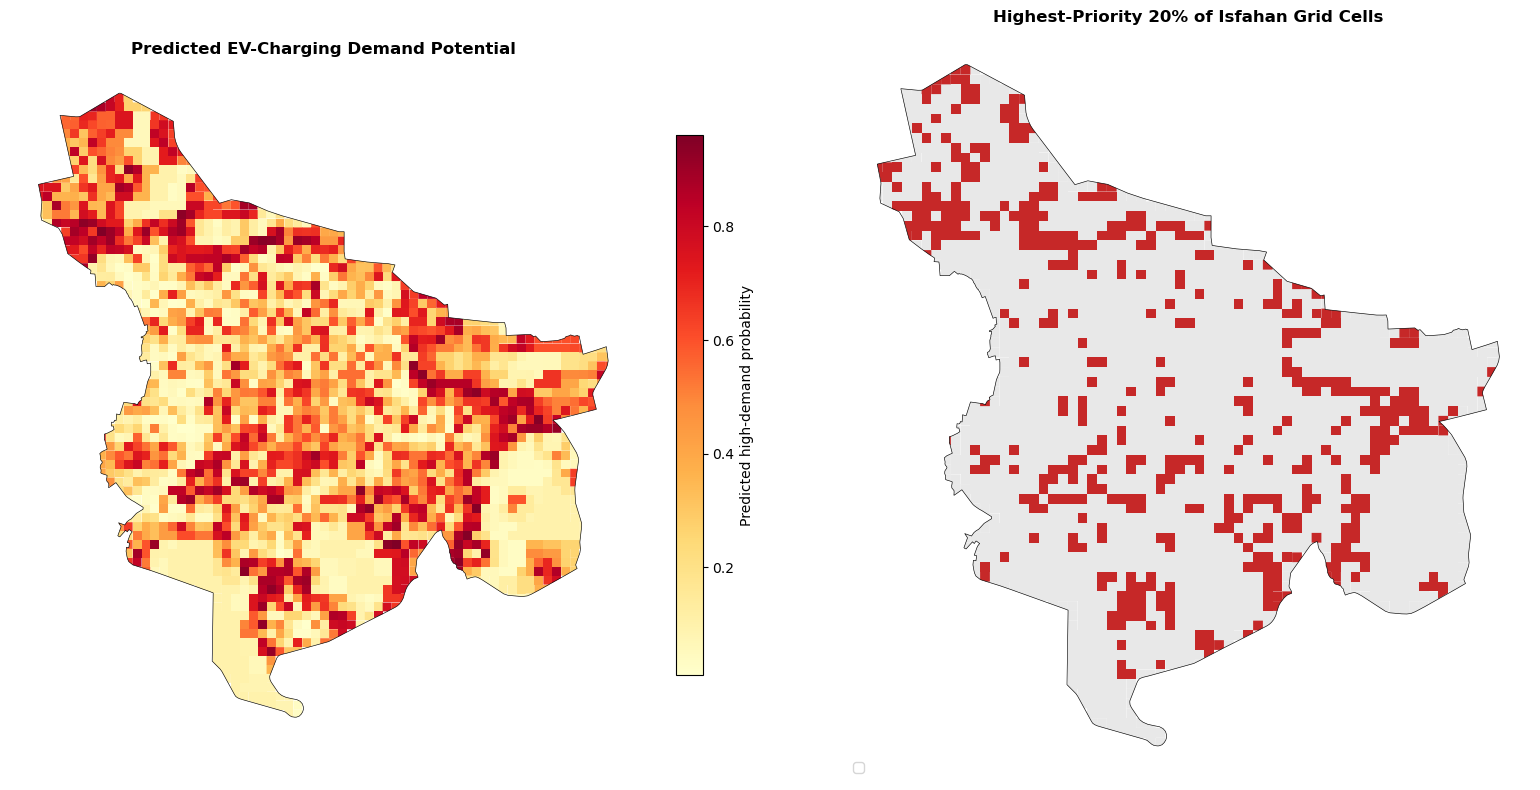

Priority cells shown: 460
Saved PNG: F:\UrbanEV_Charging_Demand\outputs\figures\isfahan_predicted_ev_charging_demand_potential.png
Saved SVG: F:\UrbanEV_Charging_Demand\outputs\figures\isfahan_predicted_ev_charging_demand_potential.svg


In [27]:
# Prompt: Create publication-ready maps of predicted EV-charging demand potential in Isfahan.

from matplotlib.colors import ListedColormap

prediction_map_png = (
    OUTPUT_FIGURES_DIR
    / "isfahan_predicted_ev_charging_demand_potential.png"
)
prediction_map_svg = (
    OUTPUT_FIGURES_DIR
    / "isfahan_predicted_ev_charging_demand_potential.svg"
)

top_priority_cells = isfahan_prediction_export.loc[
    isfahan_prediction_export["predicted_top_20_percent_priority"] == 1
].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

isfahan_prediction_export.plot(
    column="predicted_high_demand_probability",
    cmap="YlOrRd",
    linewidth=0,
    legend=True,
    legend_kwds={
        "label": "Predicted high-demand probability",
        "shrink": 0.72,
    },
    ax=axes[0],
)

isfahan_boundary.boundary.plot(
    ax=axes[0],
    color="black",
    linewidth=0.45,
)

axes[0].set_title(
    "Predicted EV-Charging Demand Potential",
    fontsize=12,
    fontweight="bold",
)
axes[0].set_axis_off()

isfahan_prediction_export.plot(
    ax=axes[1],
    color="#E8E8E8",
    linewidth=0,
)

top_priority_cells.plot(
    ax=axes[1],
    color="#C62828",
    linewidth=0,
    label="Top 20% priority cells",
)

isfahan_boundary.boundary.plot(
    ax=axes[1],
    color="black",
    linewidth=0.45,
)

axes[1].set_title(
    "Highest-Priority 20% of Isfahan Grid Cells",
    fontsize=12,
    fontweight="bold",
)
axes[1].legend(loc="lower left", frameon=True)
axes[1].set_axis_off()

fig.tight_layout()
fig.savefig(prediction_map_png, dpi=300, bbox_inches="tight")
fig.savefig(prediction_map_svg, format="svg", bbox_inches="tight")
plt.show()

print("Priority cells shown:", len(top_priority_cells))
print("Saved PNG:", prediction_map_png)
print("Saved SVG:", prediction_map_svg)

In [28]:
# Prompt: Retrieve and save mapped existing EV-charging infrastructure in Isfahan before selecting final candidate sites.

EV_CHARGING_TAGS = {
    "amenity": "charging_station",
    "man_made": "charge_point",
    "fuel:electricity": True,
}

isfahan_existing_chargers_raw = ox.features_from_polygon(
    polygon=isfahan_boundary_wgs84.geometry.iloc[0],
    tags=EV_CHARGING_TAGS,
).to_crs("EPSG:32639")

charger_index = isfahan_existing_chargers_raw.index.to_frame(index=False)

isfahan_existing_chargers = gpd.GeoDataFrame(
    {
        "osm_element": charger_index["element"].astype(str).to_numpy(),
        "osm_id": charger_index["id"].astype(str).to_numpy(),
    },
    geometry=isfahan_existing_chargers_raw.geometry.representative_point().to_numpy(),
    crs="EPSG:32639",
)

charger_output_path = INTERIM_DIR / "isfahan_existing_ev_chargers.gpkg"

isfahan_existing_chargers.to_file(
    charger_output_path,
    layer="existing_ev_chargers",
    driver="GPKG",
)

print("Mapped EV-charging features:", len(isfahan_existing_chargers))
print("\nOSM element types:")
print(isfahan_existing_chargers["osm_element"].value_counts())
print("\nSaved layer:", charger_output_path)

Mapped EV-charging features: 3

OSM element types:
osm_element
node    3
Name: count, dtype: int64

Saved layer: F:\UrbanEV_Charging_Demand\data\interim\isfahan_existing_ev_chargers.gpkg


In [29]:
# Prompt: Retrieve and save mapped existing EV-charging infrastructure in Isfahan before selecting final candidate sites.

EV_CHARGING_TAGS = {
    "amenity": "charging_station",
    "man_made": "charge_point",
    "fuel:electricity": True,
}

isfahan_existing_chargers_raw = ox.features_from_polygon(
    polygon=isfahan_boundary_wgs84.geometry.iloc[0],
    tags=EV_CHARGING_TAGS,
).to_crs("EPSG:32639")

charger_index = isfahan_existing_chargers_raw.index.to_frame(index=False)

isfahan_existing_chargers = gpd.GeoDataFrame(
    {
        "osm_element": charger_index["element"].astype(str).to_numpy(),
        "osm_id": charger_index["id"].astype(str).to_numpy(),
    },
    geometry=isfahan_existing_chargers_raw.geometry.representative_point().to_numpy(),
    crs="EPSG:32639",
)

charger_output_path = INTERIM_DIR / "isfahan_existing_ev_chargers.gpkg"

isfahan_existing_chargers.to_file(
    charger_output_path,
    layer="existing_ev_chargers",
    driver="GPKG",
)

print("Mapped EV-charging features:", len(isfahan_existing_chargers))
print("\nOSM element types:")
print(isfahan_existing_chargers["osm_element"].value_counts())
print("\nSaved layer:", charger_output_path)

Mapped EV-charging features: 3

OSM element types:
osm_element
node    3
Name: count, dtype: int64

Saved layer: F:\UrbanEV_Charging_Demand\data\interim\isfahan_existing_ev_chargers.gpkg


C:\Users\M.R.co\AppData\Local\Temp\ipykernel_8268\1923940572.py:62: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  axis.legend(loc="lower left", frameon=True)


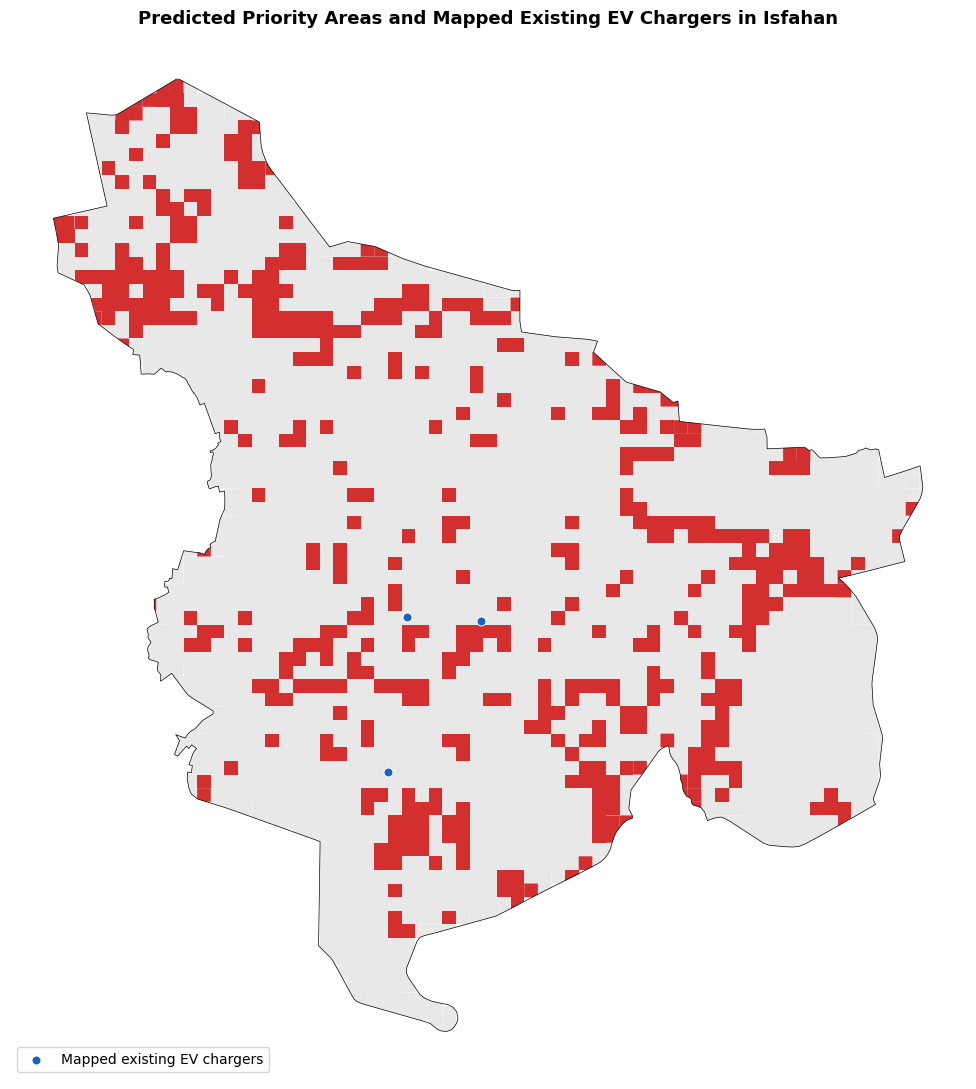

Mapped existing charging features: 3
Priority cells containing a mapped charger: 0
Matched priority-cell IDs: []


In [30]:
# Prompt: Map predicted priority cells and mapped existing EV chargers to assess their spatial overlap in Isfahan.

overlap_map_png = (
    OUTPUT_FIGURES_DIR
    / "isfahan_priority_cells_and_existing_ev_chargers.png"
)
overlap_map_svg = (
    OUTPUT_FIGURES_DIR
    / "isfahan_priority_cells_and_existing_ev_chargers.svg"
)

priority_cells_with_existing_charger = gpd.sjoin(
    top_priority_cells[["grid_id", "geometry"]],
    isfahan_existing_chargers[["osm_id", "geometry"]],
    how="inner",
    predicate="intersects",
)

priority_cells_with_existing_charger = (
    priority_cells_with_existing_charger["grid_id"]
    .drop_duplicates()
    .tolist()
)

fig, axis = plt.subplots(figsize=(11, 11))

isfahan_prediction_export.plot(
    ax=axis,
    color="#E8E8E8",
    linewidth=0,
)

top_priority_cells.plot(
    ax=axis,
    color="#D32F2F",
    linewidth=0,
    label="Predicted top-20% priority cells",
)

isfahan_existing_chargers.plot(
    ax=axis,
    color="#1565C0",
    marker="o",
    markersize=42,
    edgecolor="white",
    linewidth=0.7,
    label="Mapped existing EV chargers",
    zorder=3,
)

isfahan_boundary.boundary.plot(
    ax=axis,
    color="black",
    linewidth=0.5,
)

axis.set_title(
    "Predicted Priority Areas and Mapped Existing EV Chargers in Isfahan",
    fontsize=13,
    fontweight="bold",
)
axis.legend(loc="lower left", frameon=True)
axis.set_axis_off()

fig.tight_layout()
fig.savefig(overlap_map_png, dpi=300, bbox_inches="tight")
fig.savefig(overlap_map_svg, format="svg", bbox_inches="tight")
plt.show()

print("Mapped existing charging features:", len(isfahan_existing_chargers))
print(
    "Priority cells containing a mapped charger:",
    len(priority_cells_with_existing_charger),
)
print("Matched priority-cell IDs:", priority_cells_with_existing_charger)

In [31]:
# Prompt: Quantify whether each mapped existing EV charger falls within a model-predicted priority cell.

charger_prediction_overlap = gpd.sjoin(
    isfahan_existing_chargers,
    isfahan_prediction_export[
        [
            "grid_id",
            "predicted_high_demand_probability",
            "predicted_priority_rank",
            "predicted_top_20_percent_priority",
            "geometry",
        ]
    ],
    how="left",
    predicate="intersects",
)

charger_prediction_overlap_wgs84 = charger_prediction_overlap.to_crs("EPSG:4326")

charger_overlap_table = pd.DataFrame(
    {
        "osm_id": charger_prediction_overlap_wgs84["osm_id"],
        "longitude": charger_prediction_overlap_wgs84.geometry.x,
        "latitude": charger_prediction_overlap_wgs84.geometry.y,
        "grid_id": charger_prediction_overlap_wgs84["grid_id"],
        "predicted_probability": charger_prediction_overlap_wgs84[
            "predicted_high_demand_probability"
        ],
        "priority_rank": charger_prediction_overlap_wgs84[
            "predicted_priority_rank"
        ],
        "inside_top_20_percent_priority": charger_prediction_overlap_wgs84[
            "predicted_top_20_percent_priority"
        ],
    }
).sort_values("priority_rank")

charger_overlap_table.to_csv(
    OUTPUT_TABLES_DIR / "existing_charger_prediction_overlap.csv",
    index=False,
    encoding="utf-8-sig",
)

display(charger_overlap_table)

print(
    "Existing chargers inside predicted top-20% cells:",
    int(charger_overlap_table["inside_top_20_percent_priority"].sum()),
    "out of",
    len(charger_overlap_table),
)

,osm_id,longitude,latitude,grid_id,predicted_probability,priority_rank,inside_top_20_percent_priority
1,4396234789,51.663029,32.642027,ISF_1018,0.367679,1093,0
0,4396210791,51.692079,32.640541,ISF_1270,0.308909,1227,0
2,12709672605,51.655522,32.590454,ISF_0950,0.120819,1646,0


Existing chargers inside predicted top-20% cells: 0 out of 3


In [32]:
# Prompt: Select 15 spatially dispersed high-priority EV-charging candidate cells away from mapped existing chargers.

from shapely.geometry import Point

MIN_DISTANCE_FROM_EXISTING_CHARGER_M = 1000
MIN_DISTANCE_BETWEEN_CANDIDATES_M = 2000
NUMBER_OF_FINAL_CANDIDATES = 15

isfahan_candidate_pool = top_priority_cells.copy()

candidate_centroids = isfahan_candidate_pool.geometry.centroid
isfahan_candidate_pool["candidate_x"] = candidate_centroids.x
isfahan_candidate_pool["candidate_y"] = candidate_centroids.y

if len(isfahan_existing_chargers) > 0:
    existing_charger_union = isfahan_existing_chargers.geometry.unary_union

    isfahan_candidate_pool["distance_to_nearest_existing_charger_m"] = (
        candidate_centroids.distance(existing_charger_union)
    )
else:
    isfahan_candidate_pool["distance_to_nearest_existing_charger_m"] = np.inf

eligible_candidate_pool = (
    isfahan_candidate_pool
    .loc[
        isfahan_candidate_pool[
            "distance_to_nearest_existing_charger_m"
        ] >= MIN_DISTANCE_FROM_EXISTING_CHARGER_M
    ]
    .sort_values(
        "predicted_high_demand_probability",
        ascending=False,
    )
    .copy()
)

selected_candidate_indices = []

for candidate_index, candidate_row in eligible_candidate_pool.iterrows():
    candidate_point = Point(
        candidate_row["candidate_x"],
        candidate_row["candidate_y"],
    )

    is_far_enough_from_selected = all(
        candidate_point.distance(
            Point(
                eligible_candidate_pool.loc[selected_index, "candidate_x"],
                eligible_candidate_pool.loc[selected_index, "candidate_y"],
            )
        ) >= MIN_DISTANCE_BETWEEN_CANDIDATES_M
        for selected_index in selected_candidate_indices
    )

    if is_far_enough_from_selected:
        selected_candidate_indices.append(candidate_index)

    if len(selected_candidate_indices) == NUMBER_OF_FINAL_CANDIDATES:
        break

isfahan_preliminary_candidate_sites = (
    eligible_candidate_pool
    .loc[selected_candidate_indices]
    .copy()
    .reset_index(drop=True)
)

isfahan_preliminary_candidate_sites["candidate_rank"] = (
    np.arange(1, len(isfahan_preliminary_candidate_sites) + 1)
)

isfahan_preliminary_candidate_sites.to_file(
    INTERIM_DIR / "isfahan_preliminary_ev_charging_candidates.gpkg",
    layer="preliminary_candidates",
    driver="GPKG",
)

print("Top-20% cells before distance screening:", len(top_priority_cells))
print("Eligible cells after 1-km charger buffer:", len(eligible_candidate_pool))
print("Selected dispersed candidates:", len(isfahan_preliminary_candidate_sites))

display(
    isfahan_preliminary_candidate_sites[
        [
            "candidate_rank",
            "grid_id",
            "predicted_high_demand_probability",
            "predicted_priority_rank",
            "distance_to_nearest_existing_charger_m",
        ]
    ]
)

Top-20% cells before distance screening: 460
Eligible cells after 1-km charger buffer: 451
Selected dispersed candidates: 15


C:\Users\M.R.co\AppData\Local\Temp\ipykernel_8268\789506275.py:16: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  existing_charger_union = isfahan_existing_chargers.geometry.unary_union


,candidate_rank,grid_id,predicted_high_demand_probability,predicted_priority_rank,distance_to_nearest_existing_charger_m
0,1,ISF_1647,0.960536,1,6926.119220
1,2,ISF_0095,0.957162,2,15229.004035
2,3,ISF_1897,0.947935,3,9670.560649
3,4,ISF_2153,0.947186,5,12440.645056
4,5,ISF_0984,0.943522,6,11461.030210
5,6,ISF_0506,0.933904,8,13861.660640
6,7,ISF_0833,0.933277,9,1532.149835
7,8,ISF_1943,0.933277,10,9365.296430
8,9,ISF_1493,0.932080,12,3350.002755
9,10,ISF_0205,0.930026,15,17371.835835


In [33]:
# Prompt: Snap the 15 preliminary EV-charging candidates to their nearest drivable streets and create article-ready coordinates.

from shapely.geometry import Point

network_edge_lookup = isfahan_network_edges.reset_index().copy()

nearest_edge_ids, nearest_road_distances = ox.distance.nearest_edges(
    isfahan_drive_graph,
    X=isfahan_preliminary_candidate_sites["candidate_x"].to_numpy(),
    Y=isfahan_preliminary_candidate_sites["candidate_y"].to_numpy(),
    return_dist=True,
)

snapped_road_points = []
nearest_road_names = []

for candidate_position, (u, v, key) in enumerate(nearest_edge_ids):
    matching_edge = network_edge_lookup.loc[
        (network_edge_lookup["u"] == u)
        & (network_edge_lookup["v"] == v)
        & (network_edge_lookup["key"] == key)
    ].iloc[0]

    candidate_point = Point(
        isfahan_preliminary_candidate_sites.iloc[candidate_position]["candidate_x"],
        isfahan_preliminary_candidate_sites.iloc[candidate_position]["candidate_y"],
    )

    nearest_point_on_road = matching_edge.geometry.interpolate(
        matching_edge.geometry.project(candidate_point)
    )

    road_name = matching_edge.get("name", None)

    if isinstance(road_name, (list, tuple)):
        road_name = " / ".join(map(str, road_name))
    elif pd.isna(road_name):
        road_name = "Unnamed mapped road"

    snapped_road_points.append(nearest_point_on_road)
    nearest_road_names.append(str(road_name))

isfahan_candidate_road_points = gpd.GeoDataFrame(
    isfahan_preliminary_candidate_sites.drop(
        columns="geometry"
    ).copy(),
    geometry=snapped_road_points,
    crs="EPSG:32639",
)

isfahan_candidate_road_points["nearest_road_name"] = nearest_road_names
isfahan_candidate_road_points["distance_to_nearest_road_m"] = nearest_road_distances

candidate_road_points_wgs84 = isfahan_candidate_road_points.to_crs("EPSG:4326")

article_candidate_locations = pd.DataFrame(
    {
        "candidate_rank": candidate_road_points_wgs84["candidate_rank"],
        "grid_id": candidate_road_points_wgs84["grid_id"],
        "predicted_probability": candidate_road_points_wgs84[
            "predicted_high_demand_probability"
        ],
        "priority_rank": candidate_road_points_wgs84[
            "predicted_priority_rank"
        ],
        "longitude": candidate_road_points_wgs84.geometry.x,
        "latitude": candidate_road_points_wgs84.geometry.y,
        "nearest_road": candidate_road_points_wgs84[
            "nearest_road_name"
        ],
        "snap_distance_m": candidate_road_points_wgs84[
            "distance_to_nearest_road_m"
        ],
        "distance_to_existing_charger_m": candidate_road_points_wgs84[
            "distance_to_nearest_existing_charger_m"
        ],
    }
).sort_values("candidate_rank")

article_candidate_locations.to_csv(
    OUTPUT_TABLES_DIR / "isfahan_preliminary_ev_charging_locations.csv",
    index=False,
    encoding="utf-8-sig",
)

isfahan_candidate_road_points.to_file(
    INTERIM_DIR / "isfahan_preliminary_ev_charging_road_locations.gpkg",
    layer="candidate_road_locations",
    driver="GPKG",
)

display(article_candidate_locations)

print(
    "Maximum distance from a selected cell center to its nearest road (m):",
    round(article_candidate_locations["snap_distance_m"].max(), 1),
)

,candidate_rank,grid_id,predicted_probability,priority_rank,longitude,latitude,nearest_road,snap_distance_m,distance_to_existing_charger_m
0,1,ISF_1647,0.960536,1,51.738965,32.594375,بوستان ۵,326.130812,6926.119220
1,2,ISF_0095,0.957162,2,51.563169,32.750436,رحمانی,13.035218,15229.004035
2,3,ISF_1897,0.947935,3,51.779095,32.595288,Unnamed mapped road,151.309991,9670.560649
3,4,ISF_2153,0.947186,5,51.823735,32.654165,شهید مهدی ربانی,1.672951,12440.645056
4,5,ISF_0984,0.943522,6,51.659603,32.745505,آزادگان,47.261145,11461.030210
5,6,ISF_0506,0.933904,8,51.613160,32.757647,امیرکبیر,247.183783,13861.660640
6,7,ISF_0833,0.933277,9,51.664143,32.579840,Unnamed mapped road,1591.884692,1532.149835
7,8,ISF_1943,0.933277,10,51.786343,32.668111,Unnamed mapped road,25.548839,9365.296430
8,9,ISF_1493,0.932080,12,51.721513,32.620923,آبشار سوم (شهید آوینی),501.333589,3350.002755
9,10,ISF_0205,0.930026,15,51.577152,32.778168,ولی عصر / صنعتی,453.990760,17371.835835


Maximum distance from a selected cell center to its nearest road (m): 1591.9


In [34]:
# Prompt: Re-select 15 operationally feasible EV-charging candidates using road-access, charger-distance, and spatial-dispersion constraints.

MAX_DISTANCE_TO_DRIVABLE_ROAD_M = 250
MIN_DISTANCE_FROM_EXISTING_CHARGER_M = 1000
MIN_DISTANCE_BETWEEN_CANDIDATES_M = 2000
NUMBER_OF_FINAL_CANDIDATES = 15

isfahan_feasibility_pool = top_priority_cells.copy()

feasibility_centroids = isfahan_feasibility_pool.geometry.centroid
isfahan_feasibility_pool["candidate_x"] = feasibility_centroids.x
isfahan_feasibility_pool["candidate_y"] = feasibility_centroids.y

_, isfahan_feasibility_pool["distance_to_nearest_road_m"] = (
    ox.distance.nearest_edges(
        isfahan_drive_graph,
        X=isfahan_feasibility_pool["candidate_x"].to_numpy(),
        Y=isfahan_feasibility_pool["candidate_y"].to_numpy(),
        return_dist=True,
    )
)

if len(isfahan_existing_chargers) > 0:
    existing_charger_union = isfahan_existing_chargers.geometry.unary_union

    isfahan_feasibility_pool["distance_to_nearest_existing_charger_m"] = (
        feasibility_centroids.distance(existing_charger_union)
    )
else:
    isfahan_feasibility_pool["distance_to_nearest_existing_charger_m"] = np.inf

eligible_candidate_pool = (
    isfahan_feasibility_pool
    .loc[
        (isfahan_feasibility_pool["distance_to_nearest_road_m"]
         <= MAX_DISTANCE_TO_DRIVABLE_ROAD_M)
        & (isfahan_feasibility_pool["distance_to_nearest_existing_charger_m"]
           >= MIN_DISTANCE_FROM_EXISTING_CHARGER_M)
    ]
    .sort_values(
        "predicted_high_demand_probability",
        ascending=False,
    )
    .copy()
)

selected_candidate_indices = []

for candidate_index, candidate_row in eligible_candidate_pool.iterrows():
    candidate_point = Point(
        candidate_row["candidate_x"],
        candidate_row["candidate_y"],
    )

    is_far_enough_from_selected = all(
        candidate_point.distance(
            Point(
                eligible_candidate_pool.loc[selected_index, "candidate_x"],
                eligible_candidate_pool.loc[selected_index, "candidate_y"],
            )
        ) >= MIN_DISTANCE_BETWEEN_CANDIDATES_M
        for selected_index in selected_candidate_indices
    )

    if is_far_enough_from_selected:
        selected_candidate_indices.append(candidate_index)

    if len(selected_candidate_indices) == NUMBER_OF_FINAL_CANDIDATES:
        break

isfahan_final_candidate_sites = (
    eligible_candidate_pool
    .loc[selected_candidate_indices]
    .copy()
    .reset_index(drop=True)
)

isfahan_final_candidate_sites["candidate_rank"] = (
    np.arange(1, len(isfahan_final_candidate_sites) + 1)
)

print("Top-20% priority cells:", len(top_priority_cells))
print("Road-accessible and charger-distant cells:", len(eligible_candidate_pool))
print("Final dispersed candidates:", len(isfahan_final_candidate_sites))

display(
    isfahan_final_candidate_sites[
        [
            "candidate_rank",
            "grid_id",
            "predicted_high_demand_probability",
            "predicted_priority_rank",
            "distance_to_nearest_road_m",
            "distance_to_nearest_existing_charger_m",
        ]
    ]
)

Top-20% priority cells: 460
Road-accessible and charger-distant cells: 316
Final dispersed candidates: 15


C:\Users\M.R.co\AppData\Local\Temp\ipykernel_8268\3294793722.py:24: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  existing_charger_union = isfahan_existing_chargers.geometry.unary_union


,candidate_rank,grid_id,predicted_high_demand_probability,predicted_priority_rank,distance_to_nearest_road_m,distance_to_nearest_existing_charger_m
0,1,ISF_0095,0.957162,2,13.035218,15229.004035
1,2,ISF_1897,0.947935,3,151.309991,9670.560649
2,3,ISF_2153,0.947186,5,1.672951,12440.645056
3,4,ISF_0984,0.943522,6,47.261145,11461.030210
4,5,ISF_0506,0.933904,8,247.183783,13861.660640
5,6,ISF_1943,0.933277,10,25.548839,9365.296430
6,7,ISF_1768,0.929649,16,15.010100,7133.380058
7,8,ISF_1532,0.926485,18,181.052234,4428.274714
8,9,ISF_0995,0.913625,25,129.137079,5871.510361
9,10,ISF_1207,0.904066,39,78.901108,3285.810911


In [35]:
# Prompt: Attach the nearest drivable-road names and article-ready coordinates to the final feasible EV-charging candidates.

network_edge_lookup = isfahan_network_edges.reset_index().copy()

nearest_edge_ids, nearest_road_distances = ox.distance.nearest_edges(
    isfahan_drive_graph,
    X=isfahan_final_candidate_sites["candidate_x"].to_numpy(),
    Y=isfahan_final_candidate_sites["candidate_y"].to_numpy(),
    return_dist=True,
)

snapped_road_points = []
nearest_road_names = []

for candidate_position, (u, v, key) in enumerate(nearest_edge_ids):
    matching_edge = network_edge_lookup.loc[
        (network_edge_lookup["u"] == u)
        & (network_edge_lookup["v"] == v)
        & (network_edge_lookup["key"] == key)
    ].iloc[0]

    candidate_point = Point(
        isfahan_final_candidate_sites.iloc[candidate_position]["candidate_x"],
        isfahan_final_candidate_sites.iloc[candidate_position]["candidate_y"],
    )

    snapped_road_points.append(
        matching_edge.geometry.interpolate(
            matching_edge.geometry.project(candidate_point)
        )
    )

    road_name = matching_edge.get("name", None)

    if isinstance(road_name, (list, tuple)):
        road_name = " / ".join(map(str, road_name))
    elif pd.isna(road_name):
        road_name = "Unnamed mapped road"

    nearest_road_names.append(str(road_name))

isfahan_final_candidate_road_points = gpd.GeoDataFrame(
    isfahan_final_candidate_sites.drop(columns="geometry").copy(),
    geometry=snapped_road_points,
    crs="EPSG:32639",
)

isfahan_final_candidate_road_points["nearest_road"] = nearest_road_names
isfahan_final_candidate_road_points["snap_distance_m"] = nearest_road_distances

final_candidate_points_wgs84 = (
    isfahan_final_candidate_road_points.to_crs("EPSG:4326")
)

final_candidate_location_table = pd.DataFrame(
    {
        "candidate_rank": final_candidate_points_wgs84["candidate_rank"],
        "grid_id": final_candidate_points_wgs84["grid_id"],
        "predicted_probability": final_candidate_points_wgs84[
            "predicted_high_demand_probability"
        ],
        "priority_rank": final_candidate_points_wgs84[
            "predicted_priority_rank"
        ],
        "longitude": final_candidate_points_wgs84.geometry.x,
        "latitude": final_candidate_points_wgs84.geometry.y,
        "nearest_road": final_candidate_points_wgs84["nearest_road"],
        "snap_distance_m": final_candidate_points_wgs84["snap_distance_m"],
        "distance_to_existing_charger_m": final_candidate_points_wgs84[
            "distance_to_nearest_existing_charger_m"
        ],
    }
).sort_values("candidate_rank")

final_candidate_location_table.to_csv(
    OUTPUT_TABLES_DIR / "isfahan_final_ev_charging_candidate_locations.csv",
    index=False,
    encoding="utf-8-sig",
)

isfahan_final_candidate_road_points.to_file(
    INTERIM_DIR / "isfahan_final_ev_charging_candidate_road_locations.gpkg",
    layer="final_candidate_road_locations",
    driver="GPKG",
)

display(final_candidate_location_table)

print(
    "Maximum snap distance (m):",
    round(final_candidate_location_table["snap_distance_m"].max(), 1),
)

,candidate_rank,grid_id,predicted_probability,priority_rank,longitude,latitude,nearest_road,snap_distance_m,distance_to_existing_charger_m
0,1,ISF_0095,0.957162,2,51.563169,32.750436,رحمانی,13.035218,15229.004035
1,2,ISF_1897,0.947935,3,51.779095,32.595288,Unnamed mapped road,151.309991,9670.560649
2,3,ISF_2153,0.947186,5,51.823735,32.654165,شهید مهدی ربانی,1.672951,12440.645056
3,4,ISF_0984,0.943522,6,51.659603,32.745505,آزادگان,47.261145,11461.030210
4,5,ISF_0506,0.933904,8,51.613160,32.757647,امیرکبیر,247.183783,13861.660640
5,6,ISF_1943,0.933277,10,51.786343,32.668111,Unnamed mapped road,25.548839,9365.296430
6,7,ISF_1768,0.929649,16,51.754735,32.677071,Unnamed mapped road,15.010100,7133.380058
7,8,ISF_1532,0.926485,18,51.723975,32.610017,بوستان,181.052234,4428.274714
8,9,ISF_0995,0.913625,25,51.663368,32.536758,کمربندی غرب اصفهان,129.137079,5871.510361
9,10,ISF_1207,0.904066,39,51.685302,32.574059,Unnamed mapped road,78.901108,3285.810911


Maximum snap distance (m): 247.2


In [41]:
# Prompt: Add cached, rate-limited reverse-geocoded address labels to the 15 final Isfahan EV-charging candidates.

import json
import time
import requests

NOMINATIM_CONTACT_EMAIL = "qahramanparisa@gmail.com"
REQUEST_PAUSE_SECONDS = 15.5

if "@" not in NOMINATIM_CONTACT_EMAIL:
    raise ValueError(
        "Replace YOUR_EMAIL_HERE with an email address you control."
    )

address_cache_path = (
    INTERIM_DIR
    / "isfahan_final_candidate_reverse_geocode_cache.json"
)

if address_cache_path.exists():
    with open(address_cache_path, "r", encoding="utf-8") as cache_file:
        reverse_geocode_cache = json.load(cache_file)
else:
    reverse_geocode_cache = {}

reverse_geocode_rows = []

for _, candidate in final_candidate_location_table.iterrows():
    cache_key = (
        f"{candidate['longitude']:.6f},"
        f"{candidate['latitude']:.6f}"
    )

    if cache_key not in reverse_geocode_cache:
        response = requests.get(
            "https://nominatim.openstreetmap.org/reverse",
            params={
                "format": "jsonv2",
                "lat": candidate["latitude"],
                "lon": candidate["longitude"],
                "zoom": 17,
                "addressdetails": 1,
                "layer": "address",
                "email": NOMINATIM_CONTACT_EMAIL,
            },
            headers={
                "User-Agent": (
                    "UrbanEV-Charging-Demand-Academic-Research/1.0 "
                    f"({NOMINATIM_CONTACT_EMAIL})"
                ),
                "Accept-Language": "fa,en",
            },
            timeout=30,
        )

        response.raise_for_status()
        reverse_geocode_cache[cache_key] = response.json()

        with open(address_cache_path, "w", encoding="utf-8") as cache_file:
            json.dump(
                reverse_geocode_cache,
                cache_file,
                ensure_ascii=False,
                indent=2,
            )

        time.sleep(REQUEST_PAUSE_SECONDS)

    reverse_result = reverse_geocode_cache[cache_key]
    address_parts = reverse_result.get("address", {})

    neighborhood = next(
        (
            address_parts.get(address_key)
            for address_key in [
                "neighbourhood",
                "suburb",
                "city_district",
                "quarter",
                "village",
                "town",
            ]
            if address_parts.get(address_key)
        ),
        "Not available in OSM",
    )

    reverse_geocode_rows.append(
        {
            "candidate_rank": candidate["candidate_rank"],
            "reverse_geocoded_address": reverse_result.get(
                "display_name",
                "Not available in OSM",
            ),
            "neighborhood_or_district": neighborhood,
        }
    )

reverse_geocode_table = pd.DataFrame(reverse_geocode_rows)

final_article_location_table = (
    final_candidate_location_table
    .merge(
        reverse_geocode_table,
        on="candidate_rank",
        how="left",
        validate="one_to_one",
    )
    .sort_values("candidate_rank")
)

final_article_location_table.to_csv(
    OUTPUT_TABLES_DIR / "isfahan_final_ev_charging_article_locations.csv",
    index=False,
    encoding="utf-8-sig",
)

display(final_article_location_table)

,candidate_rank,grid_id,predicted_probability,priority_rank,longitude,latitude,nearest_road,snap_distance_m,distance_to_existing_charger_m,reverse_geocoded_address,neighborhood_or_district
0,1,ISF_0095,0.957162,2,51.563169,32.750436,رحمانی,13.035218,15229.004035,"رحمانی, منطقه ۱۲, اصفهان, بخش مرکزی شهرستان اص...",منطقه ۱۲
1,2,ISF_1897,0.947935,3,51.779095,32.595288,Unnamed mapped road,151.309991,9670.560649,"منطقه ۴, روشن دشت, اصفهان, بخش مرکزی شهرستان ا...",منطقه ۴
2,3,ISF_2153,0.947186,5,51.823735,32.654165,شهید مهدی ربانی,1.672951,12440.645056,"شهید مهدی ربانی, گورت, منطقه ۱۵, اصفهان, بخش م...",گورت
3,4,ISF_0984,0.943522,6,51.659603,32.745505,آزادگان,47.261145,11461.030210,"آزادگان, شهرک ولی عصر, مرز محله, منطقه ۷, اصفه...",مرز محله
4,5,ISF_0506,0.933904,8,51.613160,32.757647,امیرکبیر,247.183783,13861.660640,"امیرکبیر, شهرک صنعتی امیرکبیر, منطقه ۱۲, اصفها...",منطقه ۱۲
5,6,ISF_1943,0.933277,10,51.786343,32.668111,Unnamed mapped road,25.548839,9365.296430,"منطقه ۱۵, اصفهان, بخش مرکزی شهرستان اصفهان, شه...",منطقه ۱۵
6,7,ISF_1768,0.929649,16,51.754735,32.677071,Unnamed mapped road,15.010100,7133.380058,"راران, منطقه ۱۵, اصفهان, بخش مرکزی شهرستان اصف...",راران
7,8,ISF_1532,0.926485,18,51.723975,32.610017,بوستان,181.052234,4428.274714,"بوستان, کوی شهید کشوری, منطقه ۶, اصفهان, بخش م...",کوی شهید کشوری
8,9,ISF_0995,0.913625,25,51.663368,32.536758,کمربندی غرب اصفهان,129.137079,5871.510361,"کمربندی غرب اصفهان, سپاهان شهر, منطقه ۵, سپاها...",سپاهان شهر
9,10,ISF_1207,0.904066,39,51.685302,32.574059,Unnamed mapped road,78.901108,3285.810911,"محدوده ی نظامی- هوانیروز, منطقه ۶, سپاهان شهر,...",محدوده ی نظامی- هوانیروز


In [42]:
# Prompt: Identify high-priority cells affected by military, airport, prison, or waste-facility restrictions.

RESTRICTED_OSM_TAGS = {
    "landuse": "military",
    "military": True,
    "aeroway": ["aerodrome", "helipad"],
    "amenity": ["prison", "waste_disposal", "waste_transfer_station"],
}

RESTRICTION_BUFFER_METERS = 250

try:
    isfahan_restricted_features_raw = ox.features_from_polygon(
        polygon=isfahan_boundary_wgs84.geometry.iloc[0],
        tags=RESTRICTED_OSM_TAGS,
    ).to_crs("EPSG:32639")

    isfahan_restricted_features_raw = (
        isfahan_restricted_features_raw
        .loc[
            (~isfahan_restricted_features_raw.geometry.is_empty)
            & (isfahan_restricted_features_raw.geometry.notna())
        ]
        .copy()
    )
except Exception as error:
    print("No restricted OSM features retrieved:", error)

    isfahan_restricted_features_raw = gpd.GeoDataFrame(
        {"restriction_type": []},
        geometry=[],
        crs="EPSG:32639",
    )

def describe_restriction(feature_row):
    if pd.notna(feature_row.get("military")):
        return f"military: {feature_row['military']}"
    if feature_row.get("landuse") == "military":
        return "landuse: military"
    if pd.notna(feature_row.get("aeroway")):
        return f"aeroway: {feature_row['aeroway']}"
    if pd.notna(feature_row.get("amenity")):
        return f"amenity: {feature_row['amenity']}"
    return "other restricted feature"

if len(isfahan_restricted_features_raw) > 0:
    isfahan_restricted_features_raw["restriction_type"] = (
        isfahan_restricted_features_raw.apply(
            describe_restriction,
            axis=1,
        )
    )

    isfahan_restriction_buffers = gpd.GeoDataFrame(
        {
            "restriction_type": isfahan_restricted_features_raw[
                "restriction_type"
            ].to_numpy(),
        },
        geometry=(
            isfahan_restricted_features_raw.geometry
            .buffer(RESTRICTION_BUFFER_METERS)
            .to_numpy()
        ),
        crs="EPSG:32639",
    )
else:
    isfahan_restriction_buffers = gpd.GeoDataFrame(
        {"restriction_type": []},
        geometry=[],
        crs="EPSG:32639",
    )

priority_candidate_points = gpd.GeoDataFrame(
    top_priority_cells[
        [
            "grid_id",
            "predicted_high_demand_probability",
            "predicted_priority_rank",
        ]
    ].copy(),
    geometry=top_priority_cells.geometry.centroid,
    crs="EPSG:32639",
)

priority_cells_restriction_audit = gpd.sjoin(
    priority_candidate_points,
    isfahan_restriction_buffers,
    how="left",
    predicate="intersects",
)

restricted_priority_cells = (
    priority_cells_restriction_audit
    .dropna(subset="restriction_type")
    .sort_values("predicted_priority_rank")
    .copy()
)

isfahan_restriction_buffers.to_file(
    INTERIM_DIR / "isfahan_restricted_landuse_buffers.gpkg",
    layer="restricted_landuse_buffers",
    driver="GPKG",
)

print("Restricted mapped features:", len(isfahan_restricted_features_raw))
print("Priority cells affected by restrictions:", len(restricted_priority_cells))
print("\nRestriction types:")
print(isfahan_restriction_buffers["restriction_type"].value_counts())

display(
    restricted_priority_cells[
        [
            "grid_id",
            "predicted_high_demand_probability",
            "predicted_priority_rank",
            "restriction_type",
        ]
    ].head(20)
)

Restricted mapped features: 45
Priority cells affected by restrictions: 40

Restriction types:
restriction_type
landuse: military          23
military: training_area     7
military: range             5
amenity: prison             3
aeroway: helipad            3
military: airfield          2
military: bunker            1
military: checkpoint        1
Name: count, dtype: int64


,grid_id,predicted_high_demand_probability,predicted_priority_rank,restriction_type
1896,ISF_1897,0.947935,3,landuse: military
311,ISF_0312,0.907864,28,landuse: military
942,ISF_0943,0.907719,29,landuse: military
1206,ISF_1207,0.904066,39,military: airfield
674,ISF_0675,0.895581,50,aeroway: helipad
674,ISF_0675,0.895581,50,landuse: military
1925,ISF_1926,0.880597,71,landuse: military
1158,ISF_1159,0.879428,78,military: airfield
1205,ISF_1206,0.879428,79,military: airfield
898,ISF_0899,0.863805,104,landuse: military


In [43]:
# Prompt: Re-select the final 15 EV-charging candidates after excluding restricted land-use areas.

restricted_grid_ids = set(
    restricted_priority_cells["grid_id"]
    .dropna()
    .unique()
)

eligible_candidate_pool_after_restrictions = (
    isfahan_feasibility_pool
    .loc[
        (isfahan_feasibility_pool["distance_to_nearest_road_m"]
         <= MAX_DISTANCE_TO_DRIVABLE_ROAD_M)
        & (isfahan_feasibility_pool["distance_to_nearest_existing_charger_m"]
           >= MIN_DISTANCE_FROM_EXISTING_CHARGER_M)
        & (~isfahan_feasibility_pool["grid_id"].isin(restricted_grid_ids))
    ]
    .sort_values(
        "predicted_high_demand_probability",
        ascending=False,
    )
    .copy()
)

selected_candidate_indices = []

for candidate_index, candidate_row in (
    eligible_candidate_pool_after_restrictions.iterrows()
):
    candidate_point = Point(
        candidate_row["candidate_x"],
        candidate_row["candidate_y"],
    )

    is_far_enough_from_selected = all(
        candidate_point.distance(
            Point(
                eligible_candidate_pool_after_restrictions.loc[
                    selected_index,
                    "candidate_x",
                ],
                eligible_candidate_pool_after_restrictions.loc[
                    selected_index,
                    "candidate_y",
                ],
            )
        ) >= MIN_DISTANCE_BETWEEN_CANDIDATES_M
        for selected_index in selected_candidate_indices
    )

    if is_far_enough_from_selected:
        selected_candidate_indices.append(candidate_index)

    if len(selected_candidate_indices) == NUMBER_OF_FINAL_CANDIDATES:
        break

isfahan_final_candidate_sites = (
    eligible_candidate_pool_after_restrictions
    .loc[selected_candidate_indices]
    .copy()
    .reset_index(drop=True)
)

isfahan_final_candidate_sites["candidate_rank"] = (
    np.arange(1, len(isfahan_final_candidate_sites) + 1)
)

isfahan_final_candidate_sites["restriction_screen_passed"] = True

print(
    "Eligible cells after all restrictions:",
    len(eligible_candidate_pool_after_restrictions),
)
print(
    "Final dispersed candidates:",
    len(isfahan_final_candidate_sites),
)

display(
    isfahan_final_candidate_sites[
        [
            "candidate_rank",
            "grid_id",
            "predicted_high_demand_probability",
            "predicted_priority_rank",
            "distance_to_nearest_road_m",
            "distance_to_nearest_existing_charger_m",
        ]
    ]
)

Eligible cells after all restrictions: 298
Final dispersed candidates: 15


,candidate_rank,grid_id,predicted_high_demand_probability,predicted_priority_rank,distance_to_nearest_road_m,distance_to_nearest_existing_charger_m
0,1,ISF_0095,0.957162,2,13.035218,15229.004035
1,2,ISF_2153,0.947186,5,1.672951,12440.645056
2,3,ISF_0984,0.943522,6,47.261145,11461.030210
3,4,ISF_0506,0.933904,8,247.183783,13861.660640
4,5,ISF_1943,0.933277,10,25.548839,9365.296430
5,6,ISF_1864,0.933004,11,155.715824,10121.507356
6,7,ISF_1768,0.929649,16,15.010100,7133.380058
7,8,ISF_1532,0.926485,18,181.052234,4428.274714
8,9,ISF_0995,0.913625,25,129.137079,5871.510361
9,10,ISF_0843,0.903551,40,11.045615,2501.238872


In [44]:
# Prompt: Create the final article-ready table of screened Isfahan EV-charging candidate locations.

network_edge_lookup = isfahan_network_edges.reset_index().copy()

nearest_edge_ids, nearest_road_distances = ox.distance.nearest_edges(
    isfahan_drive_graph,
    X=isfahan_final_candidate_sites["candidate_x"].to_numpy(),
    Y=isfahan_final_candidate_sites["candidate_y"].to_numpy(),
    return_dist=True,
)

snapped_road_points = []
nearest_road_names = []

for candidate_position, (u, v, key) in enumerate(nearest_edge_ids):
    matching_edge = network_edge_lookup.loc[
        (network_edge_lookup["u"] == u)
        & (network_edge_lookup["v"] == v)
        & (network_edge_lookup["key"] == key)
    ].iloc[0]

    candidate_point = Point(
        isfahan_final_candidate_sites.iloc[candidate_position]["candidate_x"],
        isfahan_final_candidate_sites.iloc[candidate_position]["candidate_y"],
    )

    snapped_road_points.append(
        matching_edge.geometry.interpolate(
            matching_edge.geometry.project(candidate_point)
        )
    )

    road_name = matching_edge.get("name", None)

    if isinstance(road_name, (list, tuple)):
        road_name = " / ".join(map(str, road_name))
    elif pd.isna(road_name):
        road_name = "Unnamed mapped road"

    nearest_road_names.append(str(road_name))

isfahan_final_candidate_road_points = gpd.GeoDataFrame(
    isfahan_final_candidate_sites.drop(columns="geometry").copy(),
    geometry=snapped_road_points,
    crs="EPSG:32639",
)

isfahan_final_candidate_road_points["nearest_road"] = nearest_road_names
isfahan_final_candidate_road_points["snap_distance_m"] = nearest_road_distances

final_candidate_points_wgs84 = (
    isfahan_final_candidate_road_points.to_crs("EPSG:4326")
)

final_candidate_location_table = pd.DataFrame(
    {
        "candidate_rank": final_candidate_points_wgs84["candidate_rank"],
        "grid_id": final_candidate_points_wgs84["grid_id"],
        "predicted_probability": final_candidate_points_wgs84[
            "predicted_high_demand_probability"
        ],
        "priority_rank": final_candidate_points_wgs84[
            "predicted_priority_rank"
        ],
        "longitude": final_candidate_points_wgs84.geometry.x,
        "latitude": final_candidate_points_wgs84.geometry.y,
        "nearest_road": final_candidate_points_wgs84["nearest_road"],
        "snap_distance_m": final_candidate_points_wgs84["snap_distance_m"],
        "distance_to_existing_charger_m": final_candidate_points_wgs84[
            "distance_to_nearest_existing_charger_m"
        ],
        "restriction_screen_passed": True,
    }
).sort_values("candidate_rank")

with open(address_cache_path, "r", encoding="utf-8") as cache_file:
    reverse_geocode_cache = json.load(cache_file)

reverse_geocode_rows = []

for _, candidate in final_candidate_location_table.iterrows():
    cache_key = (
        f"{candidate['longitude']:.6f},"
        f"{candidate['latitude']:.6f}"
    )

    if cache_key not in reverse_geocode_cache:
        response = requests.get(
            "https://nominatim.openstreetmap.org/reverse",
            params={
                "format": "jsonv2",
                "lat": candidate["latitude"],
                "lon": candidate["longitude"],
                "zoom": 17,
                "addressdetails": 1,
                "layer": "address",
                "email": NOMINATIM_CONTACT_EMAIL,
            },
            headers={
                "User-Agent": (
                    "UrbanEV-Charging-Demand-Academic-Research/1.0 "
                    f"({NOMINATIM_CONTACT_EMAIL})"
                ),
                "Accept-Language": "fa,en",
            },
            timeout=30,
        )

        response.raise_for_status()
        reverse_geocode_cache[cache_key] = response.json()

        with open(address_cache_path, "w", encoding="utf-8") as cache_file:
            json.dump(
                reverse_geocode_cache,
                cache_file,
                ensure_ascii=False,
                indent=2,
            )

        time.sleep(REQUEST_PAUSE_SECONDS)

    reverse_result = reverse_geocode_cache[cache_key]
    address_parts = reverse_result.get("address", {})

    neighborhood = next(
        (
            address_parts.get(address_key)
            for address_key in [
                "neighbourhood",
                "suburb",
                "city_district",
                "quarter",
                "village",
                "town",
            ]
            if address_parts.get(address_key)
        ),
        "Not available in OSM",
    )

    reverse_geocode_rows.append(
        {
            "candidate_rank": candidate["candidate_rank"],
            "reverse_geocoded_address": reverse_result.get(
                "display_name",
                "Not available in OSM",
            ),
            "neighborhood_or_district": neighborhood,
        }
    )

final_article_location_table = (
    final_candidate_location_table
    .merge(
        pd.DataFrame(reverse_geocode_rows),
        on="candidate_rank",
        how="left",
        validate="one_to_one",
    )
    .sort_values("candidate_rank")
)

final_article_location_table.to_csv(
    OUTPUT_TABLES_DIR / "isfahan_final_ev_charging_article_locations.csv",
    index=False,
    encoding="utf-8-sig",
)

isfahan_final_candidate_road_points.to_file(
    INTERIM_DIR / "isfahan_final_ev_charging_candidate_road_locations.gpkg",
    layer="final_candidate_road_locations",
    driver="GPKG",
)

display(final_article_location_table)

,candidate_rank,grid_id,predicted_probability,priority_rank,longitude,latitude,nearest_road,snap_distance_m,distance_to_existing_charger_m,restriction_screen_passed,reverse_geocoded_address,neighborhood_or_district
0,1,ISF_0095,0.957162,2,51.563169,32.750436,رحمانی,13.035218,15229.004035,True,"رحمانی, منطقه ۱۲, اصفهان, بخش مرکزی شهرستان اص...",منطقه ۱۲
1,2,ISF_2153,0.947186,5,51.823735,32.654165,شهید مهدی ربانی,1.672951,12440.645056,True,"شهید مهدی ربانی, گورت, منطقه ۱۵, اصفهان, بخش م...",گورت
2,3,ISF_0984,0.943522,6,51.659603,32.745505,آزادگان,47.261145,11461.030210,True,"آزادگان, شهرک ولی عصر, مرز محله, منطقه ۷, اصفه...",مرز محله
3,4,ISF_0506,0.933904,8,51.613160,32.757647,امیرکبیر,247.183783,13861.660640,True,"امیرکبیر, شهرک صنعتی امیرکبیر, منطقه ۱۲, اصفها...",منطقه ۱۲
4,5,ISF_1943,0.933277,10,51.786343,32.668111,Unnamed mapped road,25.548839,9365.296430,True,"منطقه ۱۵, اصفهان, بخش مرکزی شهرستان اصفهان, شه...",منطقه ۱۵
5,6,ISF_1864,0.933004,11,51.776623,32.583317,Unnamed mapped road,155.715824,10121.507356,True,"منطقه ۴, اصفهان, بخش مرکزی شهرستان اصفهان, شهر...",منطقه ۴
6,7,ISF_1768,0.929649,16,51.754735,32.677071,Unnamed mapped road,15.010100,7133.380058,True,"راران, منطقه ۱۵, اصفهان, بخش مرکزی شهرستان اصف...",راران
7,8,ISF_1532,0.926485,18,51.723975,32.610017,بوستان,181.052234,4428.274714,True,"بوستان, کوی شهید کشوری, منطقه ۶, اصفهان, بخش م...",کوی شهید کشوری
8,9,ISF_0995,0.913625,25,51.663368,32.536758,کمربندی غرب اصفهان,129.137079,5871.510361,True,"کمربندی غرب اصفهان, سپاهان شهر, منطقه ۵, سپاها...",سپاهان شهر
9,10,ISF_0843,0.903551,40,51.647584,32.623541,جهاندار,11.045615,2501.238872,True,"جهاندار, حسین آباد, منطقه ۵, اصفهان, بخش مرکزی...",حسین آباد


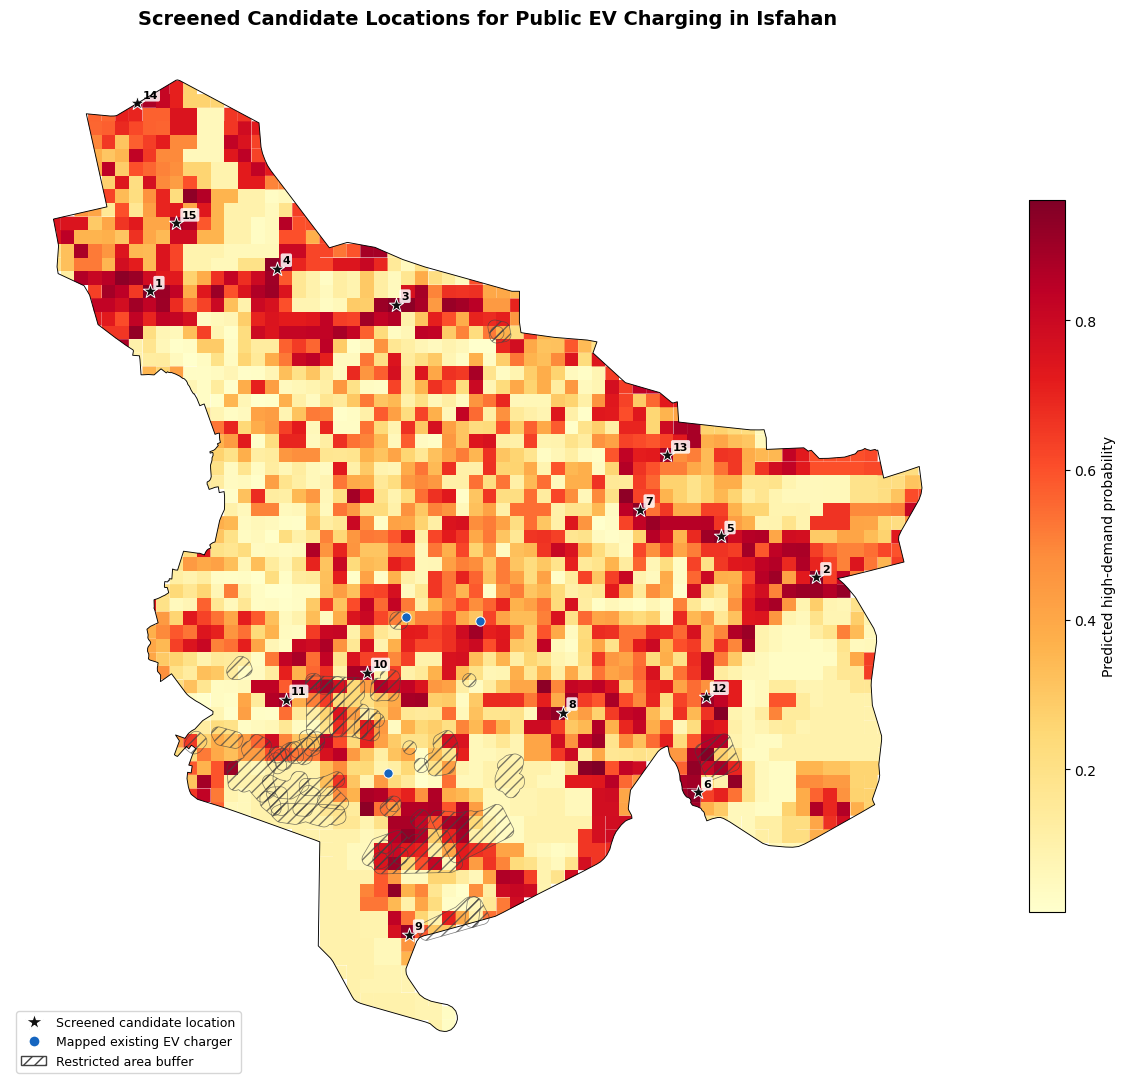

Saved PNG: F:\UrbanEV_Charging_Demand\outputs\figures\isfahan_final_screened_ev_charging_candidates.png
Saved SVG: F:\UrbanEV_Charging_Demand\outputs\figures\isfahan_final_screened_ev_charging_candidates.svg


In [45]:
# Prompt: Create a numbered final map of screened EV-charging candidates, existing chargers, and restricted areas in Isfahan.

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

final_map_png = (
    OUTPUT_FIGURES_DIR
    / "isfahan_final_screened_ev_charging_candidates.png"
)
final_map_svg = (
    OUTPUT_FIGURES_DIR
    / "isfahan_final_screened_ev_charging_candidates.svg"
)

fig, axis = plt.subplots(figsize=(13, 11))

isfahan_prediction_export.plot(
    column="predicted_high_demand_probability",
    cmap="YlOrRd",
    linewidth=0,
    legend=True,
    legend_kwds={
        "label": "Predicted high-demand probability",
        "shrink": 0.68,
    },
    ax=axis,
)

if len(isfahan_restriction_buffers) > 0:
    isfahan_restriction_buffers.plot(
        ax=axis,
        facecolor="none",
        edgecolor="#424242",
        linewidth=0.5,
        hatch="///",
        alpha=0.7,
        zorder=3,
    )

isfahan_existing_chargers.plot(
    ax=axis,
    color="#1565C0",
    marker="o",
    markersize=45,
    edgecolor="white",
    linewidth=0.7,
    zorder=5,
)

isfahan_final_candidate_road_points.plot(
    ax=axis,
    color="#111111",
    marker="*",
    markersize=115,
    edgecolor="white",
    linewidth=0.7,
    zorder=6,
)

for _, candidate in isfahan_final_candidate_road_points.iterrows():
    axis.annotate(
        text=str(int(candidate["candidate_rank"])),
        xy=(candidate.geometry.x, candidate.geometry.y),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8,
        fontweight="bold",
        color="black",
        bbox={
            "boxstyle": "round,pad=0.16",
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 0.85,
        },
        zorder=7,
    )

isfahan_boundary.boundary.plot(
    ax=axis,
    color="black",
    linewidth=0.65,
    zorder=8,
)

legend_handles = [
    Line2D(
        [0],
        [0],
        marker="*",
        color="w",
        markerfacecolor="#111111",
        markeredgecolor="white",
        markersize=13,
        label="Screened candidate location",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor="#1565C0",
        markeredgecolor="white",
        markersize=8,
        label="Mapped existing EV charger",
    ),
    Patch(
        facecolor="white",
        edgecolor="#424242",
        hatch="///",
        label="Restricted area buffer",
    ),
]

axis.legend(
    handles=legend_handles,
    loc="lower left",
    frameon=True,
    fontsize=9,
)

axis.set_title(
    "Screened Candidate Locations for Public EV Charging in Isfahan",
    fontsize=14,
    fontweight="bold",
)
axis.set_axis_off()

fig.tight_layout()
fig.savefig(final_map_png, dpi=300, bbox_inches="tight")
fig.savefig(final_map_svg, format="svg", bbox_inches="tight")
plt.show()

print("Saved PNG:", final_map_png)
print("Saved SVG:", final_map_svg)

In [46]:
# Prompt: Create a final audit table for the Isfahan screened EV-charging candidate locations.

from scipy.spatial.distance import pdist

candidate_coordinates = np.column_stack(
    [
        isfahan_final_candidate_sites["candidate_x"],
        isfahan_final_candidate_sites["candidate_y"],
    ]
)

minimum_candidate_separation_m = (
    pdist(candidate_coordinates).min()
    if len(isfahan_final_candidate_sites) > 1
    else np.nan
)

isfahan_case_study_audit = pd.DataFrame(
    [
        {
            "study_area": "Isfahan, Iran",
            "grid_resolution_m": GRID_SIZE_METERS,
            "analytical_grid_cells": len(isfahan_grid),
            "mapped_osm_pois": len(isfahan_poi_points),
            "mapped_existing_ev_chargers": len(isfahan_existing_chargers),
            "top_20_percent_priority_cells": len(top_priority_cells),
            "restricted_priority_cells": (
                restricted_priority_cells["grid_id"].nunique()
            ),
            "eligible_cells_after_all_screens": (
                len(eligible_candidate_pool_after_restrictions)
            ),
            "final_screened_candidates": (
                len(isfahan_final_candidate_sites)
            ),
            "probability_min": (
                isfahan_final_candidate_sites[
                    "predicted_high_demand_probability"
                ].min()
            ),
            "probability_max": (
                isfahan_final_candidate_sites[
                    "predicted_high_demand_probability"
                ].max()
            ),
            "probability_mean": (
                isfahan_final_candidate_sites[
                    "predicted_high_demand_probability"
                ].mean()
            ),
            "minimum_road_access_distance_m": (
                isfahan_final_candidate_sites[
                    "distance_to_nearest_road_m"
                ].min()
            ),
            "maximum_road_access_distance_m": (
                isfahan_final_candidate_sites[
                    "distance_to_nearest_road_m"
                ].max()
            ),
            "minimum_existing_charger_distance_m": (
                isfahan_final_candidate_sites[
                    "distance_to_nearest_existing_charger_m"
                ].min()
            ),
            "minimum_candidate_separation_m": (
                minimum_candidate_separation_m
            ),
        }
    ]
)

isfahan_case_study_audit.to_csv(
    OUTPUT_TABLES_DIR / "isfahan_case_study_final_audit.csv",
    index=False,
    encoding="utf-8-sig",
)

display(isfahan_case_study_audit.T)

,0
study_area,"Isfahan, Iran"
grid_resolution_m,500
analytical_grid_cells,2296
mapped_osm_pois,11475
mapped_existing_ev_chargers,3
top_20_percent_priority_cells,460
restricted_priority_cells,32
eligible_cells_after_all_screens,298
final_screened_candidates,15
probability_min,0.891729
